Point of Contact: Abigayle Hodson, Lawrence Berkeley National Laboratory (Abigayle_Hodson@lbl.gov)

Date of Last Revision: 02/12/2026

Overview: The purpose of this script is to leverage WaterTAP, an open-source, technoeconomic assessment (TEA) platform, to compare the energy consumption and cost of ultraviolet advanced oxidation process (UV AOP) technologies for premise-scale potable reuse.  More specifically, we compare the performance of standard, low-pressure (LPUV) mercury lamps to that of krypton chloride excimer (KrCl*) lamps within an existing non-potable reuse treatment train in San Francisco, CA (Project 1550). Using experimentally-determined rate constants for 0.5 log reduction of 1,4-dioxane, the standard for potable reuse in California, and N-Nitrosodimethylamine (NDMA), we model the specific energy consumption (SEC) and levelized cost of water (LCOW) necessary to meet potable reuse standards recycling greywater and blackwater in this building. We compare technology performance across doses of hydrogen peroxide (H2O2) (0 - 9 mg/L), as well as two treatment train configurations: a simplified scenario in which a single reactor is assumed capable of delivering the required UV fluence, and a more realistic scenario in which multiple UV reactors in parallel deliver the required UV fluences. Considering that the LPUV lamp currently in use at Project 1550 which is modeled herein is designed for disinfection, we also model the specific energy consumption and LCOW of acheiving potable reuse standards using Trojan's UV Fit, a commercial-grade UV AOP designed for potable reuse.

### Define functions to initialize and solve UV-AOP models

In [1]:
#import classes and functions from Pyomo optimization library
import pyomo.environ as pyo
from pyomo.environ import (ConcreteModel, Objective, Expression, value, units as pyunits, Set, log10, TransformationFactory, assert_optimal_termination)

#import flowsheet block from IDAES core
from idaes.core import FlowsheetBlock

#import unit operation models from IDAES
from idaes.models.unit_models import (
    Separator,
    Mixer,
    StateJunction,
    Feed,
    Product,
    MomentumMixingType,
    SplittingType,
)

#import function to link units in a flowsheet
from pyomo.network import Arc

#import function to get default solver
from watertap.core.solvers import get_solver

#import function to check degrees of freedom
from idaes.core.util.model_statistics import degrees_of_freedom

#import scaling utilities
import idaes.core.util.scaling as iscale

#import function to propagate state
from idaes.core.util.initialization import propagate_state

#import property models for each contaminant analyzed herein (1,4-dioxane and NDMA)
from watertap.property_models.unit_specific.dioxane_prop_pack import DioxaneParameterBlock
from watertap.property_models.unit_specific.NDMA_prop_pack import NDMAParameterBlock

#import costing model
from watertap.costing import WaterTAPCosting
from idaes.core import UnitModelCostingBlock
from watertap.costing.unit_models.uv_aop import cost_uv_aop

#import parameter sweep function for sensitivity analysis
from parameter_sweep import parameter_sweep, LinearSample

#import UV-AOP model
from watertap.unit_models.uv_aop import (Ultraviolet0D, MaterialBalanceType, EnergyBalanceType, MomentumBalanceType, UVDoseType, useDefault)

#import other libraries for data manipulation and visualization
!pip install openpyxl
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import numpy as np
import math

In [2]:
def touch_flow_and_conc(b, contaminant_type):
    """Helper function which touches basic flow and concentration variables for construction
    Args:
        b: unit model (UV AOP reactor, seperator, or mixer) or block (feed, product)
        contaminant_type (str): target contaminant being treated, either 'Dioxane' or 'NDMA'
    """
    
    #if unit is a feed or product, touch flow and concentration variables
    props = b.find_component("properties")
    if props is not None:
        props[0].flow_vol_phase
        props[0].conc_mass_phase_comp["Liq", contaminant_type]
        return

    #if unit has a control volume, touch inlet and outlet flow/concentration variables
    cv = b.find_component("control_volume")
    if cv is not None:
        cv.properties_in[0].flow_vol_phase
        cv.properties_in[0].conc_mass_phase_comp["Liq", contaminant_type]
        cv.properties_out[0].flow_vol_phase
        cv.properties_out[0].conc_mass_phase_comp["Liq", contaminant_type]
        return

    #if unit has a mixed state, touch flow and concentration variables
    b.mixed_state[0].flow_vol_phase
    b.mixed_state[0].conc_mass_phase_comp["Liq", contaminant_type]

    #if unit is a mixer, touch flow and concentration variables for each inlet stream
    if isinstance(b, Mixer):
        for x in b.config.inlet_list:
            sb = b.find_component(f"{x}_state")
            sb[0].flow_vol_phase
            sb[0].conc_mass_phase_comp["Liq", contaminant_type]

    #if unit is a separator, touch flow and concentration variables for each outlet stream
    if isinstance(b, Separator):
        for x in b.config.outlet_list:
            sb = b.find_component(f"{x}_state")
            sb[0].flow_vol_phase
            sb[0].conc_mass_phase_comp["Liq", contaminant_type]

In [3]:
def build_model(source_water, h202_cnc, lamp_type, contaminant_type, multiple_reactors, dose_override = None, flow_rate = 163.2 * pyunits.m**3 / pyunits.day):
    """Function that sets up and solves flowsheet for treatment of 1,4-dioxane and NDMA in recycled water through various UV AOP configurations
    Args:
        source_water (str): type of water being treated in UV AOP, options include 'greywater' or 'blackwater'
        h202_cnc (int): H2O2 concentration added to UV AOP (mg/L)
        lamp_type (str): type of UV lamp used, options include 'LPUV' (VIQUA PRO 30 low-pressure mercury lamp, 254-nm), 'KrCl*' (krypton chloride excimer lamp, 222-nm), or 'Alt-LPUV' (Trojan UVFit, 254-nm)
        contaminant_type (str): target contaminant being treated, either 'Dioxane' (1,4-dioxane) or 'NDMA' (N-nitrosodimethylamine)
        multiple_reactors (bool): indicates whether or not to model multiple reactors in parallel, either True or False. False represents a simplified scenario in which a single reactor is assumed capable of delivering the fluences necessary for 0.5 log reduction of 1,4-dioxane
        dose_override (float, optional): UV dose [J/m2] to override default for each scenario; toggled on when analyzing multiple reactors in parallel or NDMA degradation
        flow_rate (float, optional): total flow rate of system [m3/day]; default is 163.2 m3/day based on capacity of LPUV lamp used in Project 1550
   
     Returns:
        m (ConcreteModel): Pyomo model with added UV AOP unit model(s)
        num_reactors (int): Number of UV-AOP reactors added to the flowsheet    
    """
    
    #create a Pyomo concrete model
    m = ConcreteModel()

    #add flowsheet block to the model
    m.fs = FlowsheetBlock(dynamic = False)

    #add costing block to the flowsheet
    m.fs.costing = WaterTAPCosting()

    #add property parameter block to the flowsheet and set influent contaminant concentration, depending on target contaminant
    if contaminant_type == 'Dioxane':
        m.fs.properties = DioxaneParameterBlock()
        influent_cnc = 15 * pyunits.ug / pyunits.liter #concentration of 1,4-dioxane [ug/L] entering UV AOP reactor
    elif contaminant_type == 'NDMA':  
        m.fs.properties = NDMAParameterBlock()
        influent_cnc = 0.041 * pyunits.ug / pyunits.liter #concentration of NDMA [ug/L] entering UV AOP reactor 

    #read in parameter values needed to initialize model for each scenario (source water, target contaminant, H2O2 dose, and lamp type)
    parameters_full = pd.read_excel('input_params_by_scenario.xlsx', sheet_name = source_water)
    lamp_efficiency = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'lamp_efficiency'].values[0] #lamp efficiency [%]; how much power is converted to usable UV radiation
    reactor_volume = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'reactor_volume'].values[0] * pyunits.m**3 #reactor volume [m3]
    target_dose = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'target_dose'].values[0] * pyunits.joule / pyunits.meter**2 #experimentally-determined UV dose [J/m2] needed for 0.5 log removal of 1,4-dioxane at specified H2O2 dose
    inactivation_rate = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'inactivation_rate'].values[0] #overall inactivation rate constant for 1,4-dioxane or NDMA [m2/J]
    lamp_replacement_factor = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'lamp_replacement_factor'].values[0] #replacement factor for lamps, sleeves, ballasts and sensors [fraction of UV AOP replaced/year]
    reactor_cost = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'reactor_cost'].values[0] #cost of single UV AOP reactor [$]
    lamp_cost = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'lamp_cost'].values[0] #cost of UV lamps, sleeves, ballasts and sensors [$/kW]
    dosing_system_cost = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'dosing_system_cost'].values[0] #cost of hydrogen peroxide dosing system [$]
    irradiated_surf_area = parameters_full.loc[(parameters_full['lamp_type'] == lamp_type) & (parameters_full['h202_cnc'] == h202_cnc) & (parameters_full['contaminant_type'] == contaminant_type), 'irradiated_surface_area'].values[0] * pyunits.m**2 #irradiated surface area [m2], based on diameter of UV lamps

    #if user requests multiple reactors in parallel, set UV dose applied to maximum possible UV dose delivered per reactor (based on power rating); note that the LPUV no-oxidant scenario is excluded here due to numerical stability issues associated with > 1,000 reactors in parallel. Any resulting cost information for this scenario must be multipled by the required number of reactors.
    if (multiple_reactors == True) & ~((lamp_type == 'LPUV') & (h202_cnc == 0)):
        flow_rate_s = pyunits.convert(flow_rate, to_units=pyunits.m**3/pyunits.s)
        if lamp_type == 'LPUV':
            uv_dose_applied = 230 * pyunits.W * (0.0081 * pyunits.m**3 / flow_rate_s) / (math.pi * .103 * pyunits.m**2) * 0.375 #maximum UV dose delivered per reactor [J/m2] for LPUV (based on rated power consumption and reactor size of VIQUA PRO 30)
        elif lamp_type == 'KrCl*':
            uv_dose_applied = 500 * 8 * pyunits.W * (0.0081 * pyunits.m**3 / flow_rate_s) / (math.pi * .103 * pyunits.m**2) * 0.06 #maximum UV dose delivered per reactor [J/m2] for KrCl* excimer lamps (based on rated power consumption and reactor size of of First UVC's KrCl* lamp)
        elif lamp_type == 'Alt-LPUV':
            uv_dose_applied = (250 * 8) * pyunits.W * (0.316 * pyunits.m**3 / flow_rate_s) / (math.pi * 0.44497616502 * 2.032 * pyunits.m**2) * 0.35 #maximum UV dose delivered per reactor [J/m2] (based on rated power consumption and reactor size of TrojanUVPhox system)
    #if modeling NDMA degredation and user has specified a UV dose override, apply the override
    elif (contaminant_type == 'NDMA') & (dose_override is not None):
        uv_dose_applied = dose_override * pyunits.J / pyunits.m**2
    #otherwise, assume one reactor is capable of delivering the target UV dose for 0.5 log reduction of 1,4-dioxane
    else:
        uv_dose_applied = target_dose

    #calculate number of reactors needed in parallel to achieve target dose, if multiple reactors are requested by user
    num_reactors = value(pyo.ceil(target_dose/uv_dose_applied))

    #create lists to hold reactor and stream names
    reactor_list = [f"uv{i+1}" for i in range(num_reactors)]
    outlet_list = [f"to_uv{i+1}" for i in range(num_reactors)]
    inlet_list = [f"from_uv{i+1}" for i in range(num_reactors)]

    #initialize reactor set
    m.fs.reactor_set = Set(initialize = reactor_list)

    #for each reactor in the set, add a UV AOP unit model to the flowsheet
    for r in m.fs.reactor_set:
        if h202_cnc > 0:
            #if H2O2 is added to the system, toggle on has_aop flag; adds cost of hydrogen peroxide dosing system
            m.fs.add_component(
                r,
                Ultraviolet0D(
                    dynamic=False,
                    has_holdup=False,
                    material_balance_type=MaterialBalanceType.useDefault,
                    energy_balance_type=EnergyBalanceType.useDefault,
                    momentum_balance_type=MomentumBalanceType.pressureTotal,
                    property_package=m.fs.properties,
                    has_pressure_change=False,
                    uv_dose_type=UVDoseType.fixed,
                    has_aop=True,
                    target_species=None,
                ),
            )
        else:
            m.fs.add_component(
                r,
                Ultraviolet0D(
                    dynamic = False,
                    has_holdup = False,
                    material_balance_type = MaterialBalanceType.useDefault,
                    energy_balance_type = EnergyBalanceType.useDefault,
                    momentum_balance_type = MomentumBalanceType.pressureTotal,
                    property_package = m.fs.properties,
                    has_pressure_change = False,
                    uv_dose_type = UVDoseType.fixed,
                    has_aop = False, 
                    target_species = None,
                ),
            )
        
        #access the newly created UV AOP unit
        uv = m.fs.find_component(r)

        #touch flow/concentration variables
        touch_flow_and_conc(uv, contaminant_type)

        #set log removal expression
        uv.log_removal = Expression(
            expr=log10(
                uv.control_volume.properties_in[0].conc_mass_phase_comp["Liq", contaminant_type]
                / uv.control_volume.properties_out[0].conc_mass_phase_comp["Liq", contaminant_type]
            )
        )
        
        #add costing for each UV AOP unit
        uv.costing = UnitModelCostingBlock(flowsheet_costing_block = m.fs.costing)
        cost_uv_aop(uv.costing)
        
    #add feed stream to the flowsheet`and touch flow/concentration variables
    m.fs.feed = Feed(property_package = m.fs.properties)
    touch_flow_and_conc(m.fs.feed, contaminant_type)

    #if multiple reactors are requested, add separator and mixer to the flowsheet
    if multiple_reactors == True:
        #add seperator to the flowsheet to split feed into multiple reactors and touch flow/concentration variables
        m.fs.separator = Separator(property_package = m.fs.properties, split_basis = SplittingType.totalFlow, outlet_list = outlet_list)
        touch_flow_and_conc(m.fs.separator, contaminant_type)

        #add mixer to the flowsheet to combine reactor effluents (if applicable), and touch flow/concentration variables
        m.fs.mixer = Mixer(property_package = m.fs.properties, momentum_mixing_type = MomentumMixingType.minimize, inlet_list = inlet_list)
        touch_flow_and_conc(m.fs.mixer, contaminant_type)

    #add product stream to the flowsheet and touch flow/concentration variables
    m.fs.product = Product(property_package = m.fs.properties)
    touch_flow_and_conc(m.fs.product, contaminant_type)

    #add LCOW and SEC calculations to the costing block
    m.fs.costing.cost_process()
    m.fs.costing.add_annual_water_production(m.fs.product.properties[0].flow_vol_phase["Liq"])
    m.fs.costing.add_LCOW(flow_rate = m.fs.product.properties[0].flow_vol_phase["Liq"], name = "LCOW")
    m.fs.costing.add_specific_energy_consumption(flow_rate = m.fs.product.properties[0].flow_vol_phase["Liq"], name = "SEC")
    
    #create expressions for LCOW contributions from CAPEX and OPEX
    m.fs.costing.LCOW_capex = pyo.Expression(
        expr=(
            m.fs.costing.total_capital_cost * m.fs.costing.capital_recovery_factor
        ) / (
            pyo.units.convert(
                m.fs.product.properties[0].flow_vol_phase["Liq"],
                to_units=pyo.units.m**3 / m.fs.costing.base_period
            ) * m.fs.costing.utilization_factor
        ),
        doc="LCOW contribution from capital expenses"
    )
    m.fs.costing.LCOW_opex = pyo.Expression(
        expr=(
            m.fs.costing.total_operating_cost
        ) / (
            pyo.units.convert(
                m.fs.product.properties[0].flow_vol_phase["Liq"],
                to_units=pyo.units.m**3 / m.fs.costing.base_period
            ) * m.fs.costing.utilization_factor
        ),
        doc="LCOW contribution from operating expenses"
    )

    #link components of flowsheet (feed, seperator, reactors, mixer, product) with arcs
    if multiple_reactors == True:
        #link feed outlet to separator inlet
        m.fs.feed_to_separator = Arc(source = m.fs.feed.outlet, destination = m.fs.separator.inlet)    

        #for each UV reactor in the set, link separator outlet to reactor inlet, and reactor outlet to mixer inlet
        for r in m.fs.reactor_set:
            uv = m.fs.find_component(r)
            s = m.fs.separator.find_component(f"to_{r}")
            a = Arc(source = s, destination = uv.inlet)
            m.fs.add_component(f"sep_to_{r}", a)

            d = m.fs.mixer.find_component(f"from_{r}")
            a = Arc(source = uv.outlet, destination = d)
            m.fs.add_component(f"{r}_to_mix", a)

        #link mixer outlet to product inlet
        m.fs.mixer_to_product = Arc(source = m.fs.mixer.outlet, destination = m.fs.product.inlet)
    else:
        #link feed outlet to UV reactor inlet
        m.fs.feed_to_uv = Arc(source = m.fs.feed.outlet, destination = m.fs.uv1.inlet)

        #link UV reactor outlet directly to product inlet
        m.fs.uv_to_product = Arc(source = m.fs.uv1.outlet, destination = m.fs.product.inlet)    

    #expand arcs in the flowsheet
    TransformationFactory("network.expand_arcs").apply_to(m)

    #set feed conditions
    m.fs.feed.properties.calculate_state(
        var_args={
            ("flow_vol_phase", ("Liq")): flow_rate,
            ("conc_mass_phase_comp", ("Liq", contaminant_type)): influent_cnc,
            ("pressure", None): 101325,
            ("temperature", None): 273.15 + 25,
        },
        hold_state=True,
    )

    #create temporary variable for the number of theoretical reactors needed in parallel (needed to ensure solvable model for LPUV no-oxidant scenario, which is numerically unstable when modeling >1,000 reactors in parallel)
    if (lamp_type == 'LPUV') & (h202_cnc == 0) & (multiple_reactors == True):
        flow_rate_s = pyunits.convert(flow_rate, to_units=pyunits.m**3/pyunits.s)
        dose_new = 230 * pyunits.W * (0.0081 * pyunits.m**3 / flow_rate_s) / (math.pi * .103 * pyunits.m**2) * 0.375 #maximum UV dose delivered per reactor [J/m2] for LPUV (based on rated power consumption and reactor size of VIQUA PRO 30)
        num_reactors_temp = value(pyo.ceil(target_dose/dose_new))
    else:
        num_reactors_temp = 1   
    
    #fix costing parameters for UV AOP system
    m.fs.costing.base_currency = pyunits.USD_2023
    m.fs.costing.ultraviolet.factor_lamp_replacement.fix(lamp_replacement_factor) #replacement factor for lamps, sleeves, ballasts and sensors [fraction of UV AOP replaced/year]
    m.fs.costing.ultraviolet.reactor_cost.fix(reactor_cost * num_reactors_temp) #total cost of UV reactor(s) [$]
    m.fs.costing.ultraviolet.lamp_cost.fix(lamp_cost * num_reactors_temp) #UV lamps, sleeves, ballasts and sensors cost [$/kW]
    m.fs.costing.ultraviolet.dosing_system_cost.fix(dosing_system_cost) #cost of hydrogen peroxide dosing system [$]

    #for each UV reactor in the set, fix key model variables to ensure zero degrees of freedom
    for i, r in enumerate(m.fs.reactor_set, 1):
        #identify current reactor in iteration
        uv = m.fs.find_component(r)

        #fix lamp efficiency (%)
        uv.lamp_efficiency.fix(lamp_efficiency)

        #fix overall inactivation rate constant [m2/J]
        uv.inactivation_rate.fix(inactivation_rate)

        #fix UV dose [J/m2]
        uv.uv_dose.fix(uv_dose_applied)

        #fix reactor volume [m3]
        uv.reactor_volume.fix(reactor_volume)

        #backcalculate exposure time and fix [s]; calculated based on flow rate through each reactor (total flow rate divided by number of reactors in parallel) and reactor volume
        exposure_time = pyunits.convert(reactor_volume / (flow_rate / num_reactors), to_units = pyunits.s)
        uv.exposure_time.fix(exposure_time)

        #backcalculate electricity demand and fix [W]; calculated based on UV dose, irradiated surface area, exposure time, and lamp efficiency
        elec_demand = pyunits.convert(uv.uv_dose * irradiated_surf_area / uv.exposure_time / uv.lamp_efficiency, to_units = pyunits.W)
        uv.electricity_demand.fix(elec_demand)

        #fix additional variables if H2O2 is added to the system
        if (h202_cnc > 0):
            uv.hydrogen_peroxide_dose.fix(h202_cnc * pyunits.mg / pyunits.liter)
            uv.reaction_rate_constant.fix(0) #set to zero to avoid double counting of inactivation rate when has_aop = True (experimentally-derived inactivation rate already accounts for indirect photolysis)
            uv.uv_intensity.fix(value(uv.uv_dose)/value(uv.exposure_time)) 

        #leave one split fraction unfixed to avoid overconstraining
        if i != 1:
            m.fs.separator.split_fraction[0, f"to_{r}"].fix(1/num_reactors)

    #scale model to ensure numerical stability
    m.fs.properties.set_default_scaling(
        "flow_mass_phase_comp",
        1 / value(pyunits.convert((flow_rate / num_reactors * 1000 * pyunits.kg / pyunits.m**3), to_units = pyunits.kg / pyunits.s)),
        index=("Liq", "H2O"),
    )
    if contaminant_type == 'Dioxane':
        m.fs.properties.set_default_scaling(
            "flow_mass_phase_comp",
            1 / value(pyunits.convert(flow_rate / num_reactors * influent_cnc, to_units = pyunits.kg / pyunits.s)),
            index=("Liq", contaminant_type),
        )

    iscale.calculate_scaling_factors(m)

    #initialize separator, UV reactors, and mixer; propogate feed to separator, separator to reactors, reactors to mixer, and mixer to product
    if multiple_reactors == True:
        propagate_state(m.fs.feed_to_separator)
        m.fs.separator.initialize()

        for r in m.fs.reactor_set:
            uv = m.fs.find_component(r)
            a = m.fs.find_component(f"sep_to_{r}")
            propagate_state(a)

            uv.initialize()

            a = m.fs.find_component(f"{r}_to_mix")
            propagate_state(a)

        m.fs.mixer.initialize()
        propagate_state(m.fs.mixer_to_product)
        m.fs.product.initialize()
    else:
        propagate_state(m.fs.feed_to_uv)
        m.fs.uv1.initialize()
        propagate_state(m.fs.uv_to_product)
        m.fs.product.initialize()
    
    #initialize costing block
    m.fs.costing.initialize()

    #check that degrees of freedom is zero
    print(f"dof = {degrees_of_freedom(m)}")
    assert degrees_of_freedom(m) == 0

    #setup solver
    solver = get_solver()

    #solve model
    results = solver.solve(m, tee=False)
    assert_optimal_termination(results)

    #reset num_reactors for LPUV no-oxidant scenario if multiple reactors were requested, due to numerical stability issues associated with > 1,000 reactors in parallel
    if (lamp_type == 'LPUV') & (h202_cnc == 0) & (multiple_reactors == True):
        num_reactors = num_reactors_temp

    return m, num_reactors

### Compare UV AOPs for potable reuse of greywater

In [ ]:
#create dataframe to store energy/cost results for each lamp and H2O2 dose (assuming multiple reactors in parallel are required to deliver UV doses for 0.5 log reduction of 1,4-dioxane)
base_diox_LCOW = pd.DataFrame(columns=['h202_cnc', 'lamp_type', 'LCOW', 'specific_energy_consumption', 'LCOW_capex', 'LCOW_opex','num_reactors'])

#iterate through oxidant doses and lamp types
for h202_cnc in [0, 3, 6, 9]:
    for lamp_type in ['LPUV', 'KrCl*','Alt-LPUV']:        
        #solve baseline model
        m, num_reactors = build_model('greywater', h202_cnc, lamp_type, 'Dioxane', True)

        #append modeling results to dataframe for comparing scenarios
        base_diox_LCOW.loc[len(base_diox_LCOW)] = [
            h202_cnc,
            lamp_type,
            value(m.fs.costing.LCOW),
            value(m.fs.costing.SEC),
            value(m.fs.costing.LCOW_capex),
            value(m.fs.costing.LCOW_opex),
            num_reactors,
        ]

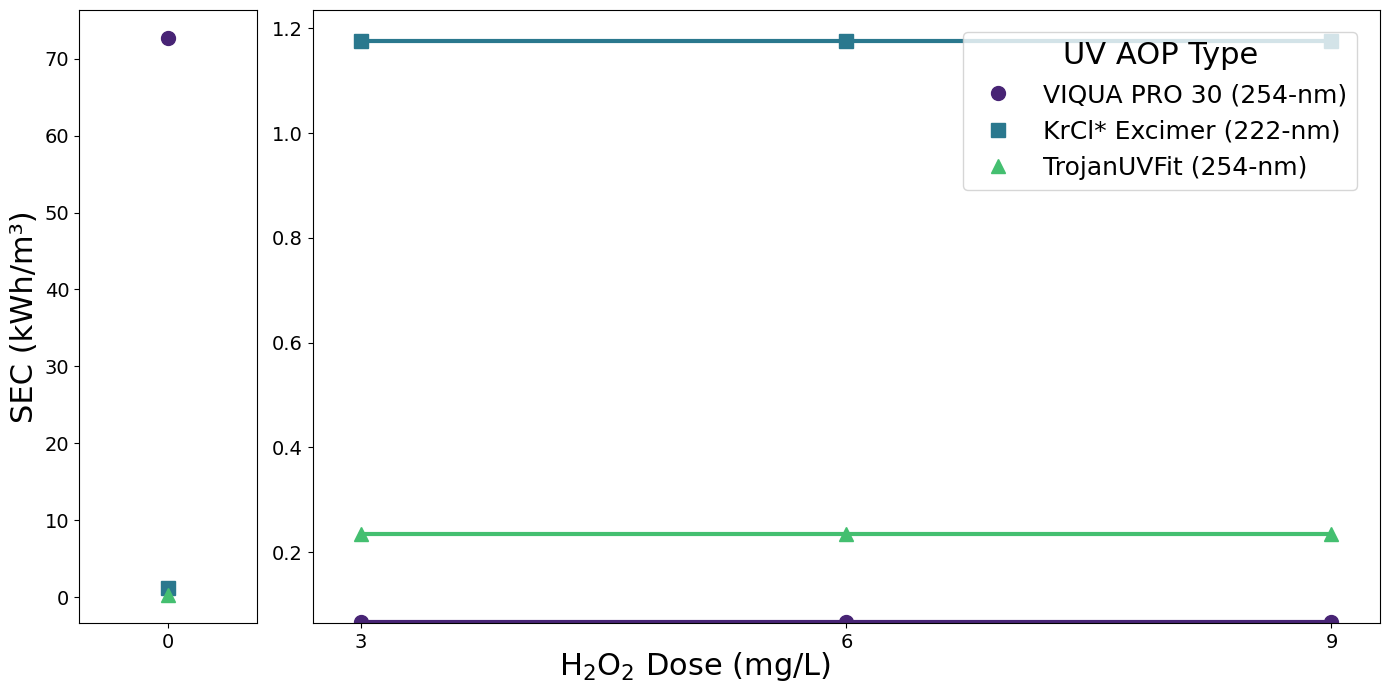

In [30]:
#create plot of specific energy consumption versus H2O2 dose for each lamp type (figure 2a)
from matplotlib.cm import viridis
import matplotlib.lines as mlines

fig, (ax0, ax1) = plt.subplots(
    ncols=2,
    figsize=(14, 8),
    sharey=False,  # allow independent y-axis for second panel
    gridspec_kw={'width_ratios': [0.5, 3]}  # first panel narrower
)

lamp_types = ['LPUV', 'KrCl*', 'Alt-LPUV']
colors = [viridis(0.1), viridis(0.4), viridis(0.7)]
markers = ['o', 's', '^']  # circle, square, triangle

# --- Left panel (H2O2 = 0) ---
for lamp, color, marker in zip(lamp_types, colors, markers):
    subset = base_diox_LCOW[
        (base_diox_LCOW['lamp_type'] == lamp) &
        (base_diox_LCOW['h202_cnc'] == 0)
    ]
    ax0.plot(
        subset['h202_cnc'],
        subset['specific_energy_consumption'],
        marker=marker,
        linestyle='None',
        color=color,
        markersize=10
    )

ax0.set_xticks([0])
ax0.tick_params(labelsize=14)
ax0.set_ylabel('SEC (kWh/m³)', fontsize=22)

# --- Right panel (H2O2 > 0) ---
for lamp, color, marker in zip(lamp_types, colors, markers):
    subset = base_diox_LCOW[
        (base_diox_LCOW['lamp_type'] == lamp) &
        (base_diox_LCOW['h202_cnc'] > 0)
    ]
    ax1.plot(
        subset['h202_cnc'],
        subset['specific_energy_consumption'],
        marker=marker,
        linewidth=3,
        color=color,
        markersize=10
    )

ax1.set_xticks([3, 6, 9])
ax1.tick_params(labelsize=14)

ymin = base_diox_LCOW[base_diox_LCOW['h202_cnc'] > 0]['specific_energy_consumption'].min()
ymax = base_diox_LCOW[base_diox_LCOW['h202_cnc'] > 0]['specific_energy_consumption'].max()
ax1.set_ylim(ymin * 0.95, ymax * 1.05)

fig.supxlabel('H$_2$O$_2$ Dose (mg/L)', fontsize=22, y=0.04)

# --- Legend with matching markers ---
fig.legend(
    handles=[
        mlines.Line2D([], [], color=colors[0], marker=markers[0], linestyle='None', markersize=10),
        mlines.Line2D([], [], color=colors[1], marker=markers[1], linestyle='None', markersize=10),
        mlines.Line2D([], [], color=colors[2], marker=markers[2], linestyle='None', markersize=10)
    ],
    labels=['VIQUA PRO 30 (254-nm)', 'KrCl* Excimer (222-nm)', 'TrojanUVFit (254-nm)'],
    title="UV AOP Type",
    fontsize=18,
    title_fontsize=22,
    loc='upper right',
    ncol=1,
    bbox_to_anchor=(0.982, 0.87)
)

for ax in (ax0, ax1):
    ax.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('figure_2a.jpeg', bbox_inches='tight')
plt.show()

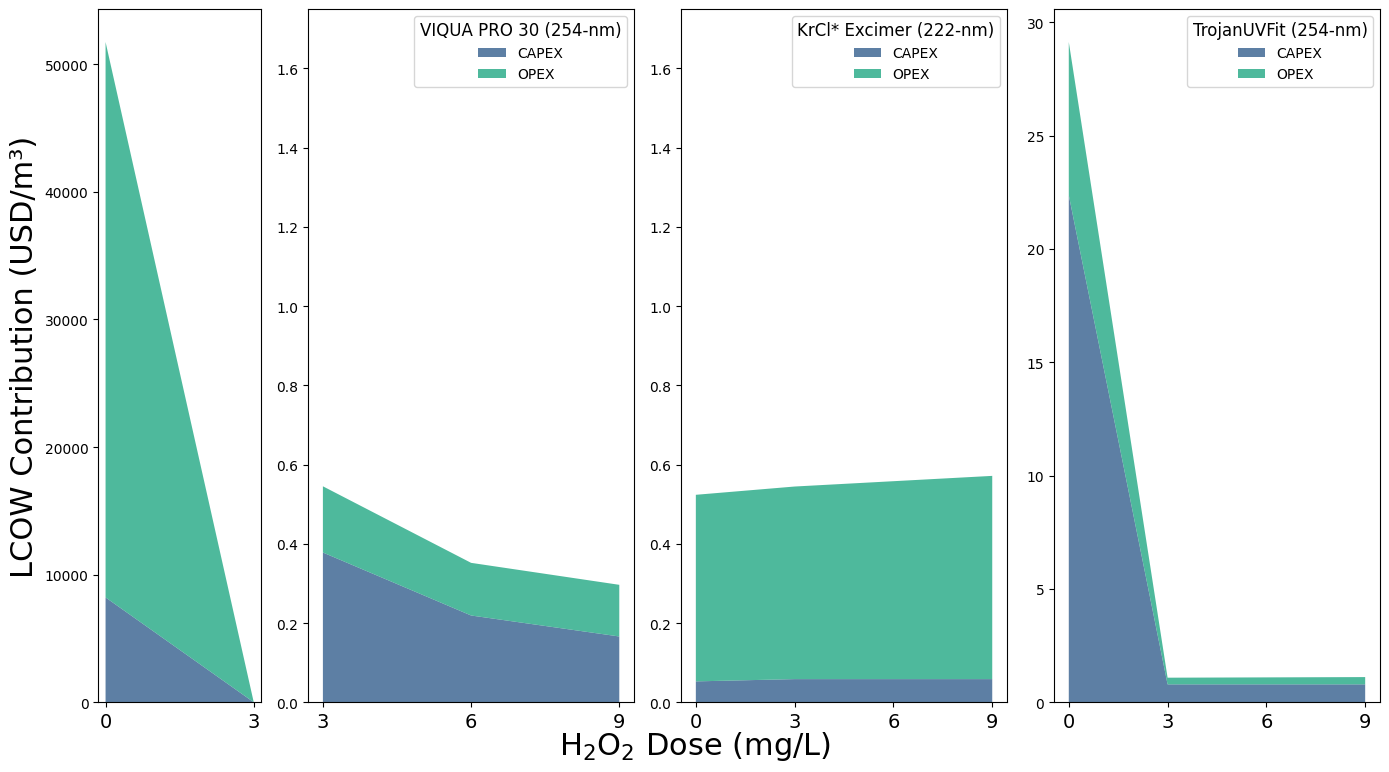

In [53]:
#create plot of capital expenditure (CAPEX) and operating expenditure (OPEX) versus H2O2 dose for each lamp type (figure 2b and c)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, figsize=(14, 8), sharex=False, sharey=False, gridspec_kw={'width_ratios': [0.5, 1, 1, 1]})

#plot stacked area chart of cost for VIQUA PRO 30 lamp
subset = base_diox_LCOW[(base_diox_LCOW['lamp_type'] == 'LPUV') & (base_diox_LCOW['h202_cnc'] <= 3)]
h2o2_dose = subset['h202_cnc']
capex = subset['LCOW_capex']
opex = subset['LCOW_opex']
ax1.stackplot(h2o2_dose, capex, opex, labels = ['CAPEX', 'OPEX'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

subset = base_diox_LCOW[(base_diox_LCOW['lamp_type'] == 'LPUV') & (base_diox_LCOW['h202_cnc'] >= 3)]
h2o2_dose = subset['h202_cnc']
capex = subset['LCOW_capex']
opex = subset['LCOW_opex']
ax2.stackplot(h2o2_dose, capex, opex, labels = ['CAPEX', 'OPEX'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

#plot stacked area chart of cost for KrCl* lamp
subset = base_diox_LCOW[base_diox_LCOW['lamp_type'] == 'KrCl*']
h2o2_dose = subset['h202_cnc']
capex = subset['LCOW_capex']
opex = subset['LCOW_opex']
ax3.stackplot(h2o2_dose, capex, opex, labels = ['CAPEX', 'OPEX'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

#plot stacked area chart of cost for TrojanUVFit lamp
subset = base_diox_LCOW[base_diox_LCOW['lamp_type'] == 'Alt-LPUV']
h2o2_dose = subset['h202_cnc']
capex = subset['LCOW_capex']
opex = subset['LCOW_opex']
ax4.stackplot(h2o2_dose, capex, opex, labels = ['CAPEX', 'OPEX'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

#format plot
fig.supxlabel('H$_2$O$_2$ Dose (mg/L)', fontsize=22, y=0.04)
ax1.set_ylabel('LCOW Contribution (USD/m³)', fontsize = 22)
ax1.grid(False)
# ax1.legend(title = "VIQUA PRO 30 (254-nm)", fontsize = 10, title_fontsize = 12)
ax2.legend(title = "VIQUA PRO 30 (254-nm)", fontsize = 10, title_fontsize = 12)
ax3.legend(title = "KrCl* Excimer (222-nm)", fontsize = 10, title_fontsize = 12)
ax4.legend(title = "TrojanUVFit (254-nm)", fontsize = 10, title_fontsize = 12)
ax1.set_xticks([0, 3])
ax1.set_xticklabels([0, 3], fontsize = 14)
ax2.set_xticks([3, 6, 9])
ax2.set_xticklabels([3, 6, 9], fontsize = 14)
ax3.set_xticks([0, 3, 6, 9])
ax3.set_xticklabels([0, 3, 6, 9], fontsize = 14)
ax4.set_xticks([0, 3, 6, 9])
ax4.set_xticklabels([0, 3, 6, 9], fontsize = 14)
ax2.set_ylim([0, 1.75])
ax3.set_ylim([0, 1.75])
plt.tight_layout()

#export figure
plt.savefig('figure_2b_c.jpeg', bbox_inches = 'tight')
plt.show()

In [ ]:
# #check average NDMA removal across H2O2 doses necessary to achieve 0.5 log removal of 1,4-dioxane
# print("Average NDMA log removal for LPUV lamp: ", base_NDMA_LCOW.loc[base_NDMA_LCOW['lamp_type'] == 'LPUV', 'log_removal'].mean())
# print("Average NDMA log removal for KrCl* lamp: ", base_NDMA_LCOW.loc[base_NDMA_LCOW['lamp_type'] == 'KrCl*', 'log_removal'].mean())

Average NDMA log removal for LPUV lamp:  3.7496402509812015
Average NDMA log removal for KrCl* lamp:  0.9406369279924058


In [ ]:
# #initialize dataframe to hold UV dose versus log removal of NDMA data for each lamp type
# base_ndma_lr = pd.DataFrame(columns=['lamp_type', 'uv_dose','LCOW', 'specific_energy_consumption','LCOW_capex', 'LCOW_opex', 'dose_check', 'log_removal'])

# #initialize baseline model for NDMA degradation by both lamp types (assuming one lamp can deliver required UV dose)
# for lamp_type in ['LPUV', 'KrCl*']:
#     #set lower and upper bounds for UV dose [J/m^2]
#     lower_bound = 1
#     upper_bound = 10000

#     #solve baseline model at different UV doses to generate UV dose vs log removal curve
#     for dose in range(lower_bound, upper_bound+100, 1000):
#         m, num_reactors = build_model('greywater', 0, lamp_type, 'NDMA', False, dose_override = dose)          
#         #add UV dose vs log removal data to dataframe for comparing scenarios
#         base_ndma_lr.loc[len(base_ndma_lr)] = [
#             lamp_type,
#             dose,
#             value(m.fs.costing.LCOW),
#             value(m.fs.costing.SEC),
#             value(m.fs.costing.LCOW_capex),
#             value(m.fs.costing.LCOW_opex),
#             value(m.fs.uv1.uv_dose),
#             value(m.fs.uv1.log_removal),
#         ]

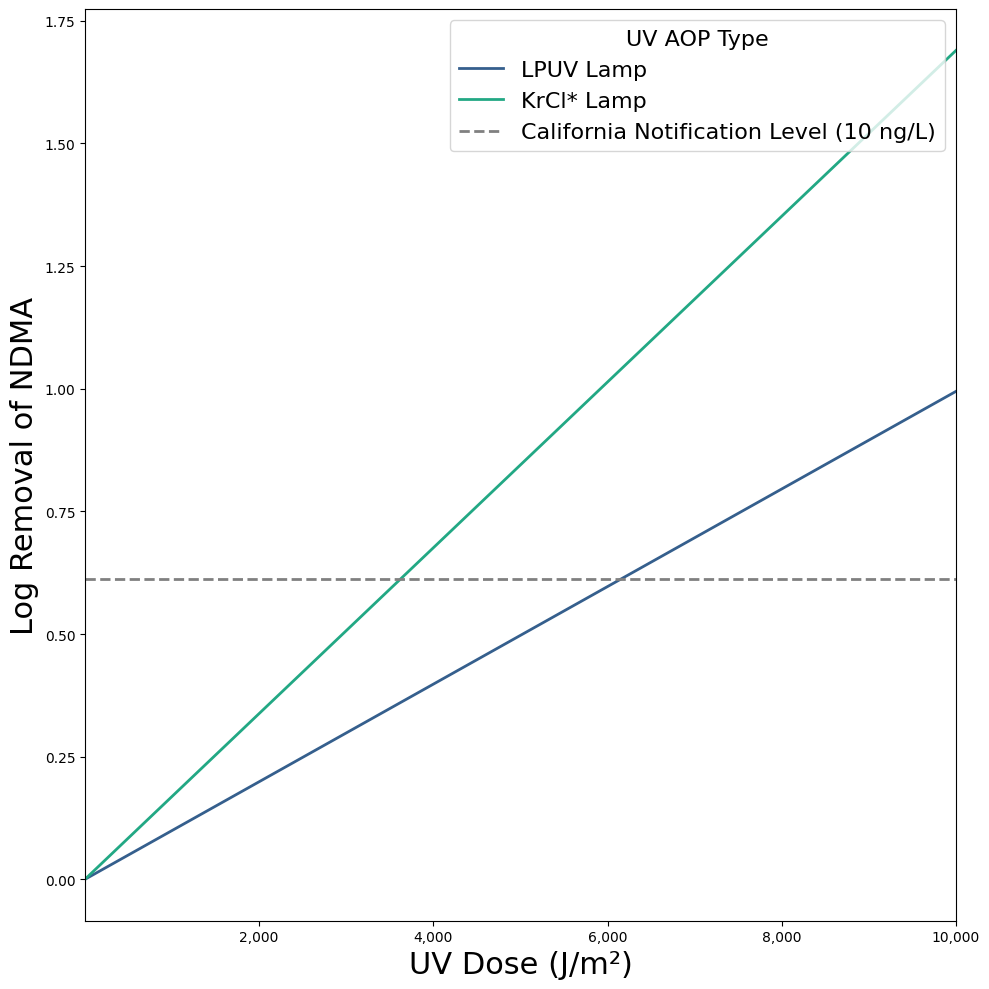

In [ ]:
# #create plot of UV dose versus NDMA log removal for each lamp type (Figure 2)
# fig, ax = plt.subplots(figsize=(10, 10), sharex=True)

# #plot line chart of log removal versus UV dose for LPUV lamp
# subset = base_ndma_lr[base_ndma_lr['lamp_type'] == 'LPUV']
# ax.plot(subset['uv_dose'], subset['log_removal'], label = 'LPUV Lamp', color = viridis(0.3), linewidth = 2)

# #plot line chart of log removal versus UV dose for KrCl* lamp
# subset = base_ndma_lr[base_ndma_lr['lamp_type'] == 'KrCl*']
# ax.plot(subset['uv_dose'], subset['log_removal'], label = 'KrCl* Lamp', color = viridis(0.6), linewidth = 2)

# #add horizontal line for 0.613 log removal (reduces NDMA concentration to 10 ng/L, the California notification limit)
# ax.plot([lower_bound, upper_bound], [0.613, 0.613], color='gray', linestyle='--', linewidth = 2)

# #format plot
# def format_with_commas(x, pos):
#     return f'{int(x):,}'
# ax.xaxis.set_major_formatter(FuncFormatter(format_with_commas))
# ax.set_ylabel('Log Removal of NDMA', fontsize = 22)
# ax.set_xlabel('UV Dose (J/m²)', fontsize = 22)
# ax.grid(False)
# ax.legend(title = "UV AOP Type", fontsize = 18, title_fontsize = 22)
# ax.set_xlim([lower_bound, upper_bound])
# line = mlines.Line2D([], [], color = 'gray', linestyle='--', linewidth = 2, label = 'California Notification Level (10 ng/L)')
# ax.legend(handles=ax.get_legend_handles_labels()[0] + [line], labels=ax.get_legend_handles_labels()[1] + ['California Notification Level (10 ng/L)'], title="UV AOP Type", fontsize=16, title_fontsize=16, loc='upper right')

# #export figure
# plt.tight_layout()
# plt.savefig('figure_3.jpeg', bbox_inches='tight')
# plt.show()

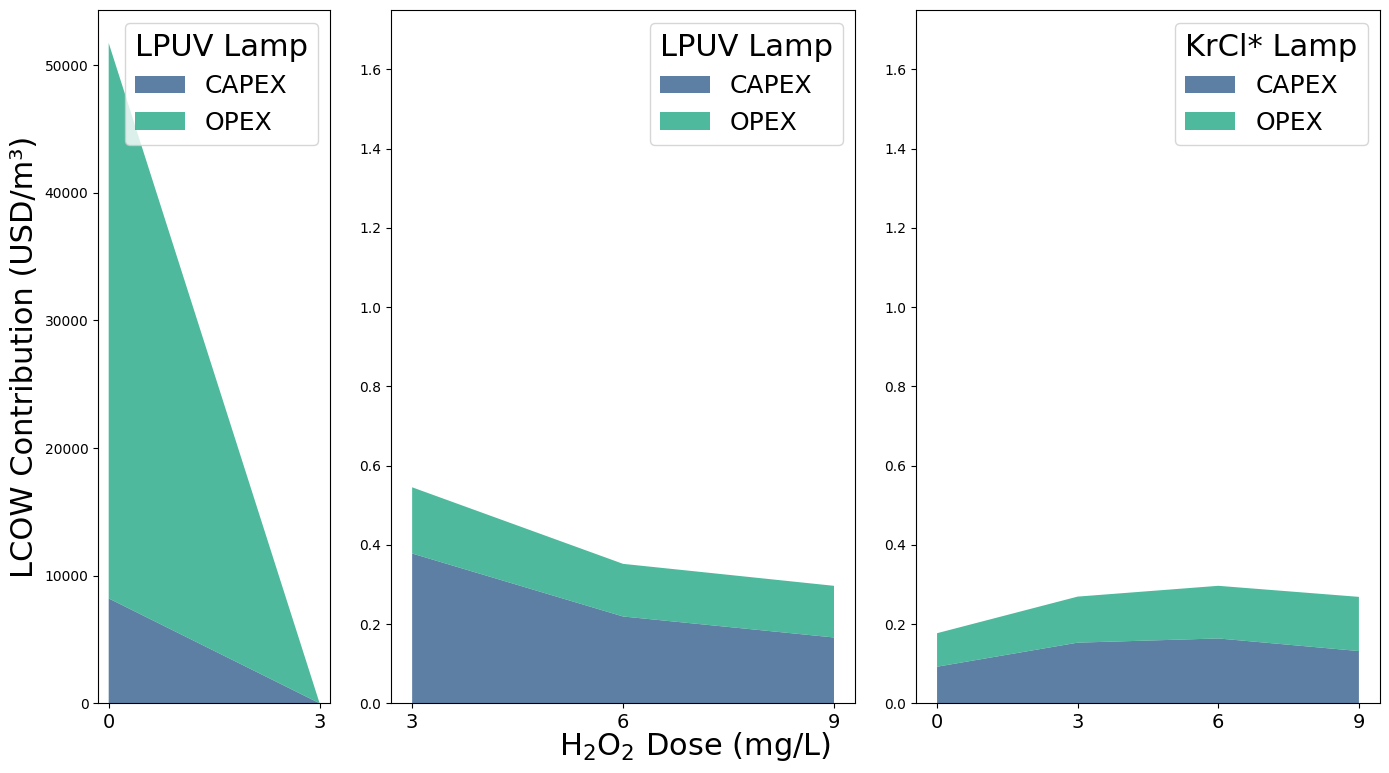

In [ ]:
# #create plot of CAPEX and OPEX versus H2O2 dose for each lamp type, assuming multiple reactors in parallel are required to deliver UV doses for 0.5 log reduction of 1,4-dioxane (figure 4)
# fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(14, 8), sharex=False, sharey=False, gridspec_kw={'width_ratios': [1, 2, 2]})

# #plot stacked area chart of cost for LPUV lamp
# subset = base_diox_LCOW[(base_diox_LCOW['lamp_type'] == 'LPUV') & (base_diox_LCOW['h202_cnc'] <= 3)]
# h2o2_dose = subset['h202_cnc']
# capex = subset['LCOW_capex']
# opex = subset['LCOW_opex']
# ax1.stackplot(h2o2_dose, capex, opex, labels = ['CAPEX', 'OPEX'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

# subset = base_diox_LCOW[(base_diox_LCOW['lamp_type'] == 'LPUV') & (base_diox_LCOW['h202_cnc'] >= 3)]
# h2o2_dose = subset['h202_cnc']
# capex = subset['LCOW_capex']
# opex = subset['LCOW_opex']
# ax2.stackplot(h2o2_dose, capex, opex, labels = ['CAPEX', 'OPEX'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

# #plot stacked area chart of cost for KrCl* lamp
# subset = base_diox_LCOW[base_diox_LCOW['lamp_type'] == 'KrCl*']
# h2o2_dose = subset['h202_cnc']
# capex = subset['LCOW_capex']
# opex = subset['LCOW_opex']
# ax3.stackplot(h2o2_dose, capex, opex, labels = ['CAPEX', 'OPEX'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

# #format plot
# fig.supxlabel('H$_2$O$_2$ Dose (mg/L)', fontsize=22, y=0.04)
# ax1.set_ylabel('LCOW Contribution (USD/m³)', fontsize = 22)
# ax1.grid(False)
# ax1.legend(title = "LPUV Lamp", fontsize = 18, title_fontsize = 22, alignment = 'left')
# ax2.legend(title = "LPUV Lamp", fontsize = 18, title_fontsize = 22, alignment = 'left')
# ax3.legend(title = "KrCl* Lamp", fontsize = 18, title_fontsize = 22, alignment = 'left')
# ax1.set_xticks([0, 3])
# ax1.set_xticklabels([0, 3], fontsize = 14)
# ax2.set_xticks([3, 6, 9])
# ax2.set_xticklabels([3, 6, 9], fontsize = 14)
# ax3.set_xticks([0, 3, 6, 9])
# ax3.set_xticklabels([0, 3, 6, 9], fontsize = 14)
# ax2.set_ylim([0, 1.75])
# ax3.set_ylim([0, 1.75])
# plt.tight_layout()

# #export figure
# plt.savefig('figure_4.jpeg', bbox_inches = 'tight')
# plt.show()

# #NTS- OPEX FOR MUTLIPLE LAMPS SOMEHOW LOWER FOR MULTIPLE REACTORS THAN SINGLE REACTOR; AM I INTERPRETING LAMP COST VARIABLE CORRECTLY?

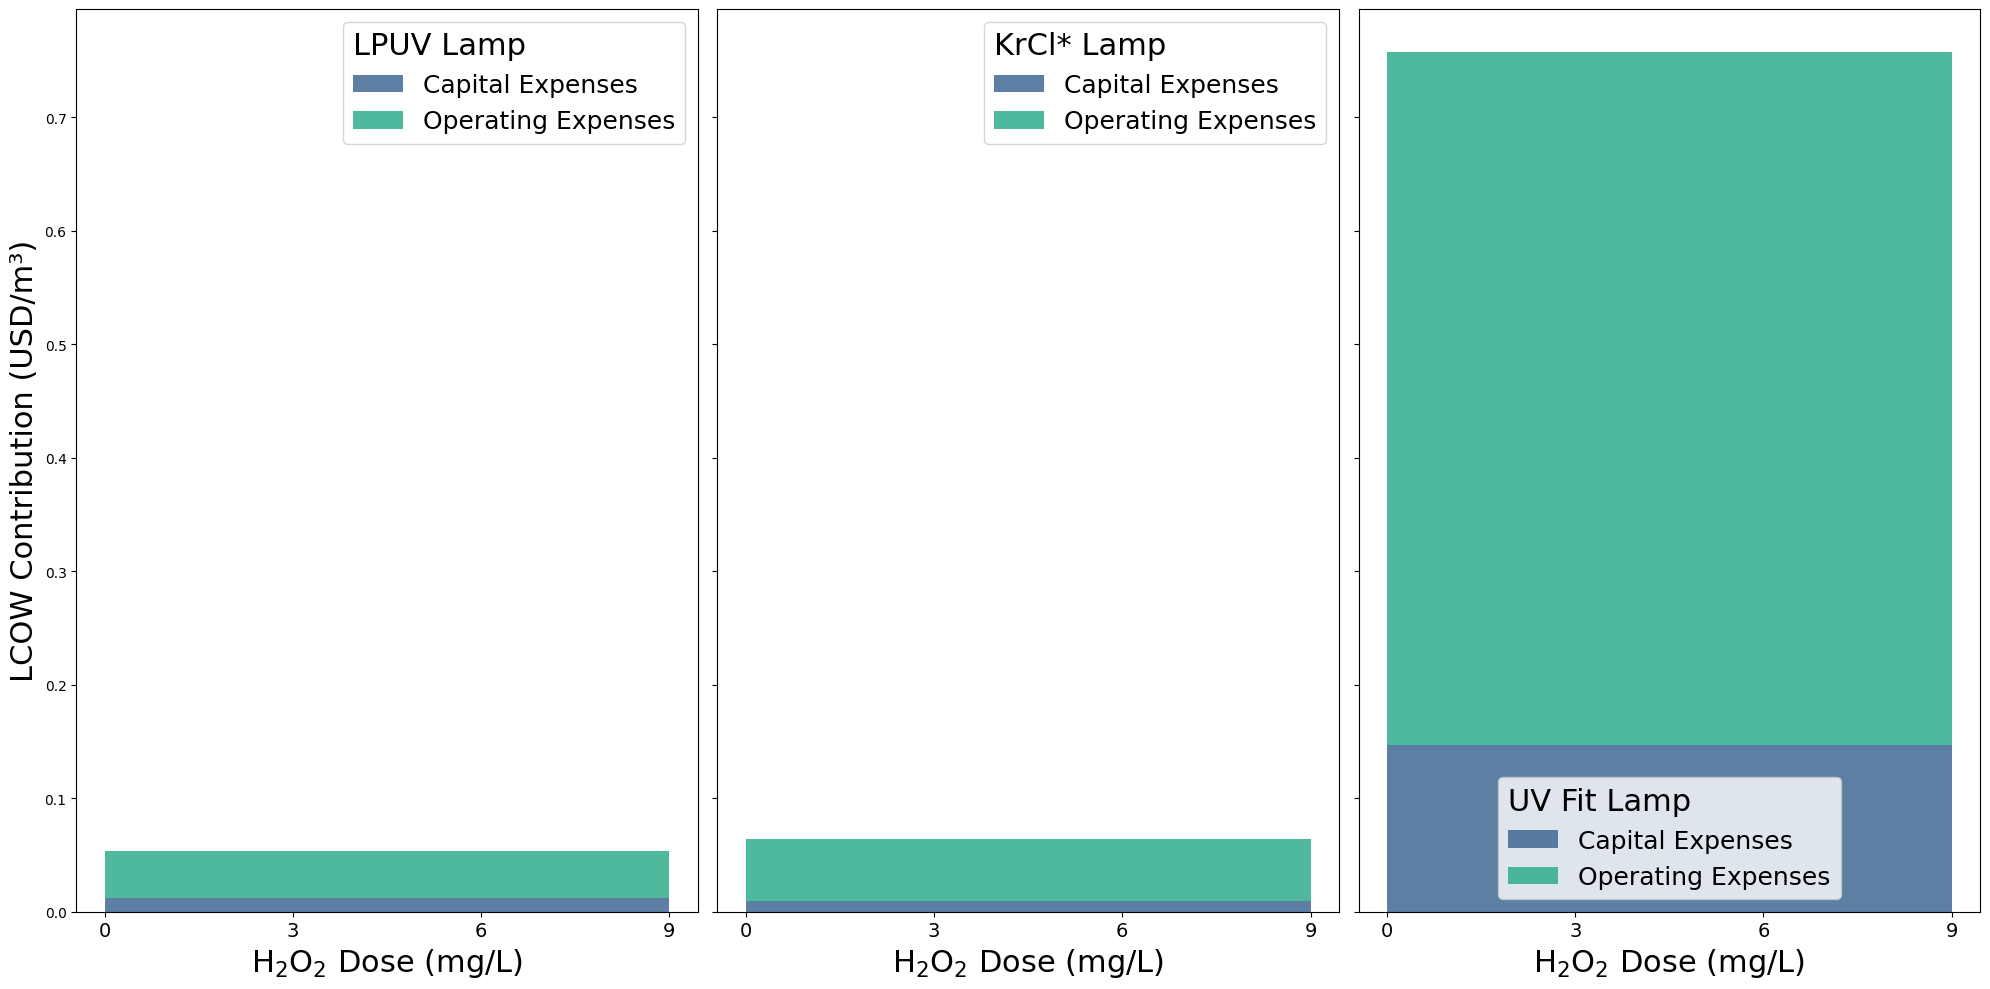

In [ ]:
# #create plot of CAPEX and OPEX versus H2O2 for each lamp type, including alternative LPUV, assuming multiple reactors in parallel are required to deliver UV doses for 0.5 log reduction of 1,4-dioxane (figure 4)
# fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(20, 10), sharex=True, sharey=True)

# #plot stacked area chart of cost for LPUV lamp
# subset = base_diox_LCOW[base_diox_LCOW['lamp_type'] == 'LPUV']
# h2o2_dose = subset['h202_cnc']
# capex = subset['LCOW_capex']
# opex = subset['LCOW_opex']
# ax1.stackplot(h2o2_dose, capex, opex, labels=['Capital Expenses', 'Operating Expenses'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

# #plot stacked area chart of cost for KrCl* lamp
# subset = base_diox_LCOW[base_diox_LCOW['lamp_type'] == 'KrCl*']
# h2o2_dose = subset['h202_cnc']
# capex = subset['LCOW_capex']
# opex = subset['LCOW_opex']
# ax2.stackplot(h2o2_dose, capex, opex, labels=['Capital Expenses', 'Operating Expenses'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

# #plot stacked area chart of cost for TrojanUVPhox lamp
# subset = base_diox_LCOW[base_diox_LCOW['lamp_type'] == 'Alt-LPUV']
# h2o2_dose = subset['h202_cnc']
# capex = subset['LCOW_capex']
# opex = subset['LCOW_opex']
# ax3.stackplot(h2o2_dose, capex, opex, labels=['Capital Expenses', 'Operating Expenses'], alpha = 0.8, colors = [viridis(0.3), viridis(0.6)])

# #format plot
# ax1.set_xlabel('H$_2$O$_2$ Dose (mg/L)', fontsize = 22)
# ax2.set_xlabel('H$_2$O$_2$ Dose (mg/L)', fontsize = 22)
# ax3.set_xlabel('H$_2$O$_2$ Dose (mg/L)', fontsize = 22)
# ax1.set_ylabel('LCOW Contribution (USD/m³)', fontsize = 22)
# ax1.grid(False)
# ax1.legend(title="LPUV Lamp", fontsize = 18, title_fontsize = 22, alignment = 'left')
# ax2.legend(title="KrCl* Lamp", fontsize = 18, title_fontsize = 22, alignment = 'left')
# ax3.legend(title="UV Fit Lamp", fontsize = 18, title_fontsize = 22, alignment = 'left')
# ax1.set_xticks([0, 3, 6, 9])
# ax1.set_xticklabels([0, 3, 6, 9], fontsize = 14)
# ax2.set_xticks([0, 3, 6, 9])
# ax2.set_xticklabels([0, 3, 6, 9], fontsize = 14)
# ax3.set_xticks([0, 3, 6, 9])
# ax3.set_xticklabels([0, 3, 6, 9], fontsize = 14)
# plt.tight_layout()

# #export figure
# plt.savefig('figure_4.jpeg', bbox_inches = 'tight')
# plt.show()

### Analyze sensitivity of UV AOP performance to flow rate and lamp replacement factor

In [ ]:
#define functions to assess sensitivity of LCOW and specific energy consumption to flow rate
def build_sweep_params(model, **kwargs):
    """Define parameters to vary and their ranges"""
    sweep_params = dict()
    sweep_params['Flow Rate'] = LinearSample(m.fs.product.properties[0].flow_vol_phase["Liq"], 1.89, 6.31, 10) #30-100 gpm in kg/s
    return sweep_params

def build_outputs(model, **kwargs):
    """Define outputs to track"""
    outputs = dict()
    outputs['LCOW'] = model.fs.costing.LCOW
    outputs['Specific Energy Consumption'] = model.fs.costing.specific_energy_consumption
    return outputs

#run the parameter sweep across evaluated flow rates, lamp types, and H2O2 doses 
for h202_cnc in [1, 2, 3, 4]:
    for lamp_type in ['LPUV', 'KrCl*']:
        try:
            #build the model once per iteration
            model, _ = build_model(h202_cnc, lamp_type, 'Dioxane', True)
            
            #define sweep parameters and outputs
            sweep_params = build_sweep_params(model)
            outputs = build_outputs(model)
            
            #run the parameter sweep and export results to CSV
            parameter_sweep(
                model,
                sweep_params,
                outputs,
                csv_results_file_name=f'sensitivity_results_TEA_{h202_cnc}_{lamp_type}.csv',
            )
            print(f"Parameter sweep completed successfully for TEA scenario {h202_cnc} and lamp type {lamp_type}.")
        except Exception as e:
            print(f"Error during parameter sweep for TEA scenario {h202_cnc} and lamp type {lamp_type}: {e}")

2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_in[0.0].flow_mass_phase_comp[Liq,H2O]
2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_in[0.0].flow_mass_phase_comp[Liq,Dioxane]
2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_out[0.0].flow_mass_phase_comp[Liq,H2O]
2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_out[0.0].flow_mass_phase_comp[Liq,Dioxane]
2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.uv_intensity
2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.exposure_time
2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.uv_dose
2025-12-22 09:58:42 [WARNING] idaes.core.util.scaling: 

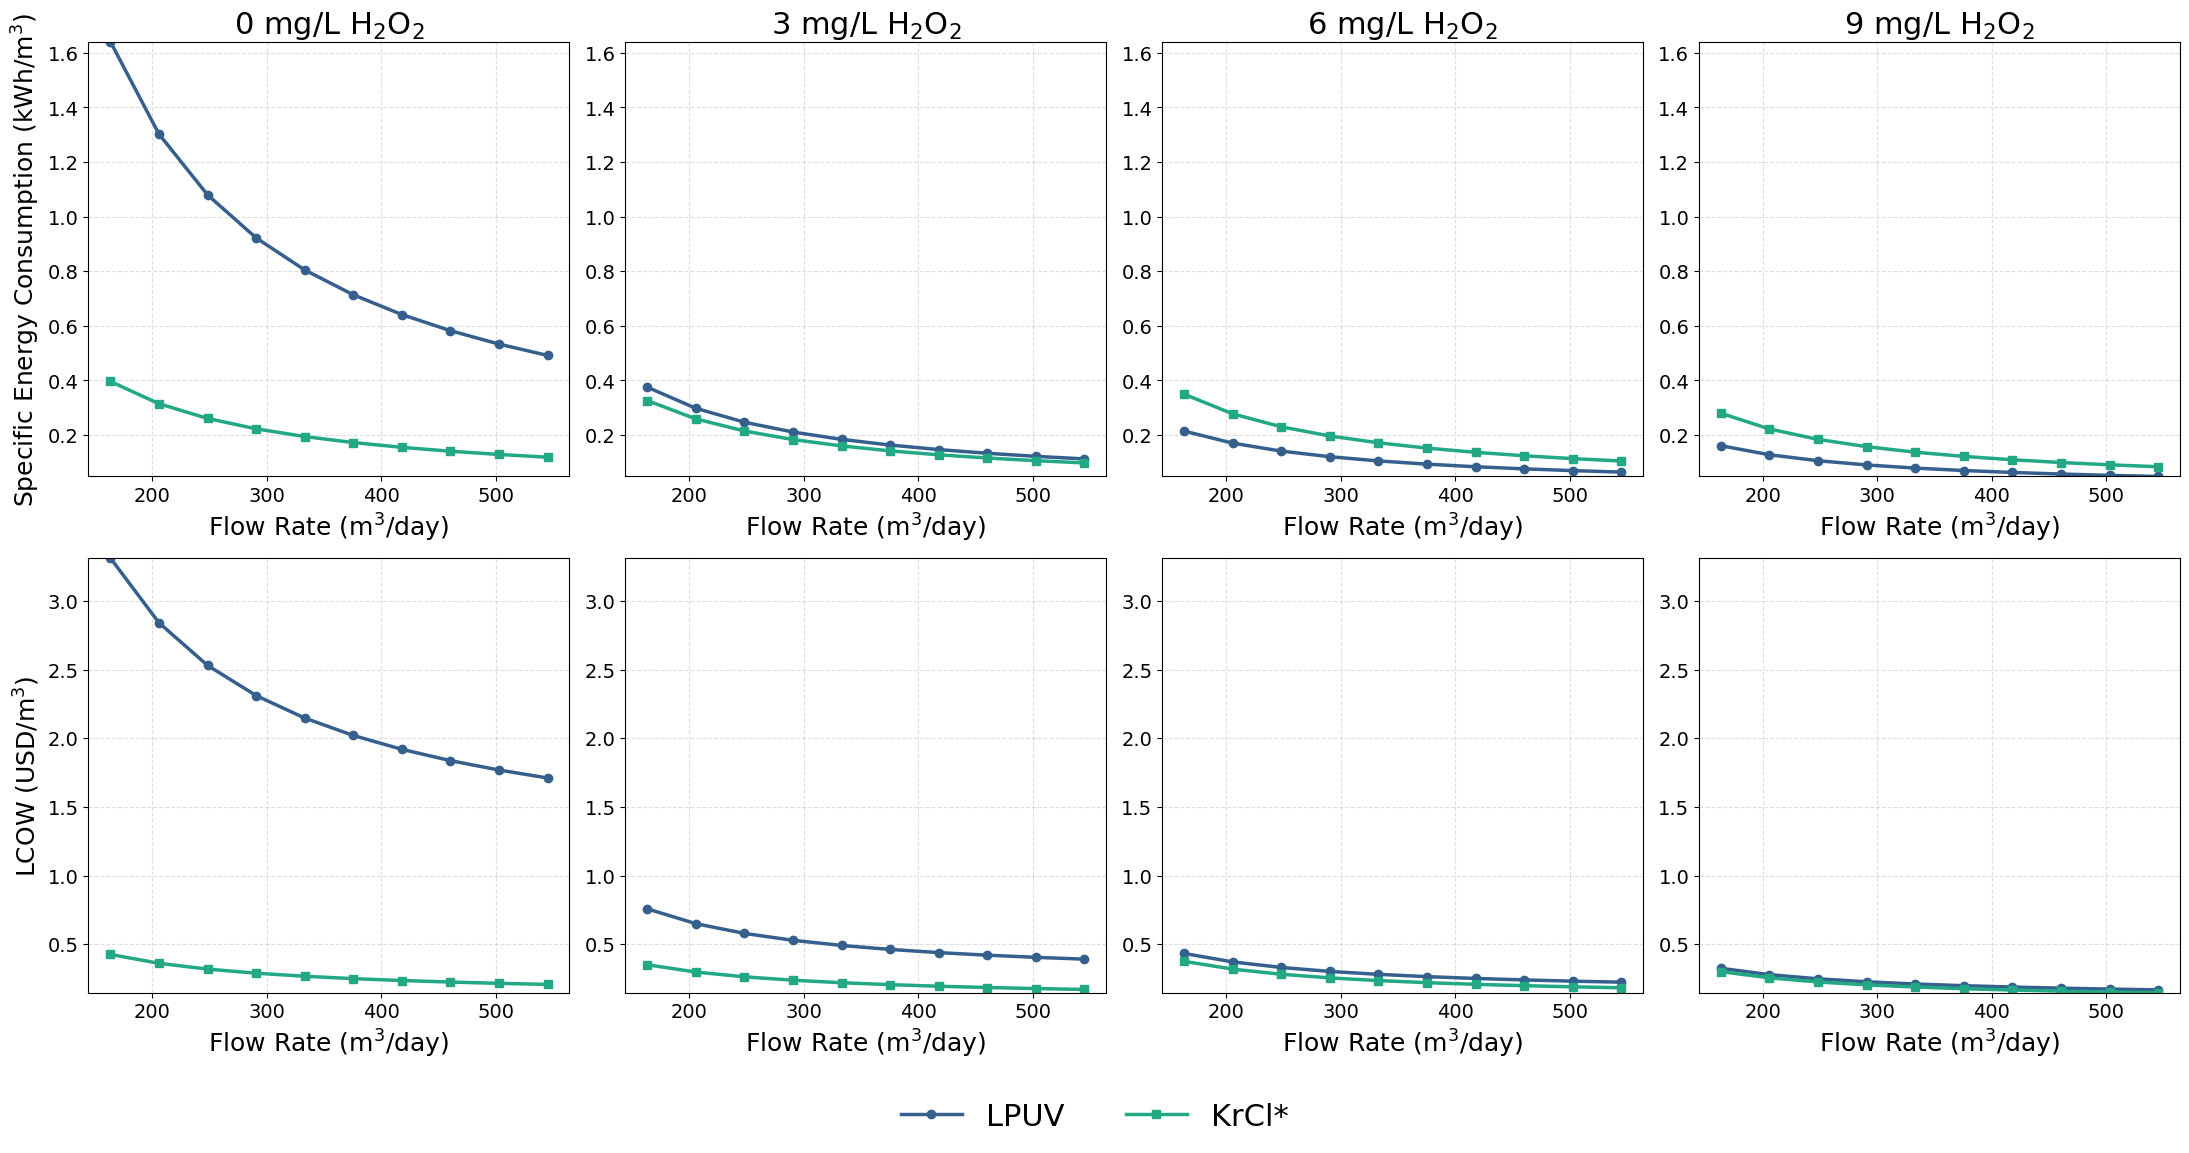

In [ ]:
#create line plots of specific energy consumption and LCOW vs flow rate for each lamp type and H2O2 dose (figure 5)
fig, axes = plt.subplots(2, 4, figsize = (22, 12), sharey = False)
markers = {"LPUV": "o", "KrCl*": "s"}
colors  = {"LPUV": viridis(0.3), "KrCl*": viridis(0.6)}

titles = {
    0: "0 mg/L H$_2$O$_2$",
    3: "3 mg/L H$_2$O$_2$",
    6: "6 mg/L H$_2$O$_2$",
    9: "9 mg/L H$_2$O$_2$",
}

#reformat parameter sweep results for plotting
SEC_data  = {"LPUV": {}, "KrCl*": {}}
LCOW_data = {"LPUV": {}, "KrCl*": {}}
for lamp_type in ['LPUV', 'KrCl*']:
    for i in [0, 3, 6, 9]:
        #load in parameter sweep data
        df = pd.read_csv(f"sensitivity_results_TEA_{i}_{lamp_type}.csv")

        # convert flow rate to m3/day
        df['# Flow Rate'] = df['# Flow Rate'] * 86.4

        SEC_data[lamp_type][i]  = df[['# Flow Rate', 'Specific Energy Consumption']]
        LCOW_data[lamp_type][i] = df[['# Flow Rate', 'LCOW']]

#compute shared y-axis limits for specific energy consumption and LCOW
SEC_min = min(SEC_data[lamp][i]['Specific Energy Consumption'].min()
              for lamp in ['LPUV','KrCl*'] for i in [0, 3, 6, 9])
SEC_max = max(SEC_data[lamp][i]['Specific Energy Consumption'].max()
              for lamp in ['LPUV','KrCl*'] for i in [0, 3, 6, 9])
LCOW_min = min(LCOW_data[lamp][i]['LCOW'].min()
               for lamp in ['LPUV','KrCl*'] for i in [0, 3, 6, 9])
LCOW_max = max(LCOW_data[lamp][i]['LCOW'].max()
               for lamp in ['LPUV','KrCl*'] for i in [0, 3, 6, 9])

#iterate through H2O2 doses and plot specific energy consumption versus flow rate
for idx, TEA in enumerate([0, 3, 6, 9]):
    ax = axes[0, idx]

    for lamp_type in ['LPUV', 'KrCl*']:
        df = SEC_data[lamp_type][TEA]
        ax.plot(
            df['# Flow Rate'],
            df['Specific Energy Consumption'],
            marker = markers[lamp_type],
            color = colors[lamp_type],
            linewidth = 2.5,
            label = lamp_type
        )

    ax.set_title(f"{titles[TEA]}", fontsize=22)
    ax.set_xlabel(r"Flow Rate (m$^3$/day)", fontsize=18)
    ax.set_ylim(SEC_min, SEC_max)
    ax.grid(True, linestyle = "--", alpha = 0.4)
    ax.tick_params(axis = "both", labelsize = 14)

axes[0, 0].set_ylabel(r"Specific Energy Consumption (kWh/m$^3$)", fontsize = 18)

#iterate through H2O2 doses and plot LCOW versus flow rate
for idx, TEA in enumerate([0, 3, 6, 9]):
    ax = axes[1, idx]

    for lamp_type in ['LPUV', 'KrCl*']:
        df = LCOW_data[lamp_type][TEA]
        ax.plot(
            df['# Flow Rate'],
            df['LCOW'],
            marker = markers[lamp_type],
            color = colors[lamp_type],
            linewidth = 2.5
        )

    ax.set_xlabel(r"Flow Rate (m$^3$/day)", fontsize = 18)
    ax.set_ylim(LCOW_min, LCOW_max)
    ax.grid(True, linestyle = "--", alpha=0.4)
    ax.tick_params(axis = "both", labelsize = 14)

axes[1, 0].set_ylabel(r"LCOW (USD/m$^3$)", fontsize = 18)

fig.legend(
    ["LPUV", "KrCl*"],
    loc="lower center",
    ncol = 2,
    fontsize = 22,
    frameon = False,
    bbox_to_anchor = (0.5, -0.02)
)

fig.tight_layout(rect=[0, 0.05, 1, 0.95])

#export figure
plt.savefig("figure_5a_b.jpeg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#define functions to assess sensitivity of LCOW and specific energy consumption to lamp replacement factor
def build_sweep_params(model, **kwargs):
    """Define parameters to vary and their ranges"""
    sweep_params = dict()
    sweep_params['Flow Rate'] = LinearSample(m.fs.product.properties[0].flow_vol_phase["Liq"], 1.89, 6.31, 10) #30-100 gpm in kg/s
    sweep_params['Lamp Replacement Factor'] = LinearSample(model.fs.costing.ultraviolet.factor_lamp_replacement, 0.5, 2, 10) #replace twice a year to once every two years
    return sweep_params

def build_outputs(model, **kwargs):
    """Define outputs to track"""
    outputs = dict()
    outputs['LCOW'] = model.fs.costing.LCOW
    outputs['Specific Energy Consumption'] = model.fs.costing.specific_energy_consumption
    return outputs

#run the parameter sweep across evaluated lamp replacement factors, lamp types, and H2O2 doses 
for h202_cnc in [0, 3, 6, 9]:
    for lamp_type in ['LPUV', 'KrCl*']:
        try:
            #build the model once per iteration
            model, _, _ = build_model(h202_cnc, lamp_type, 'Dioxane', True)
            
            #define sweep parameters and outputs
            sweep_params = build_sweep_params(model)
            outputs = build_outputs(model)
            
            #run the parameter sweep
            parameter_sweep(
                model,
                sweep_params,
                outputs,
                csv_results_file_name=f'sensitivity_results_TEA_{h202_cnc}_{lamp_type}.csv',
            )
            print(f"Parameter sweep completed successfully for TEA scenario {h202_cnc} and lamp type {lamp_type}.")
        except Exception as e:
            print(f"Error during parameter sweep for TEA scenario {h202_cnc} and lamp type {lamp_type}: {e}")

2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_in[0.0].flow_mass_phase_comp[Liq,H2O]
2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_in[0.0].flow_mass_phase_comp[Liq,Dioxane]
2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_out[0.0].flow_mass_phase_comp[Liq,H2O]
2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.control_volume.properties_out[0.0].flow_mass_phase_comp[Liq,Dioxane]
2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.uv_intensity
2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.exposure_time
2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.unit_1.uv_dose
2025-12-22 09:59:27 [WARNING] idaes.core.util.scaling: 

/var/folders/y1/85r4w0515p15jzrs10_jj1980000gp/T/ipykernel_8860/522962178.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/y1/85r4w0515p15jzrs10_jj1980000gp/T/ipykernel_8860/522962178.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


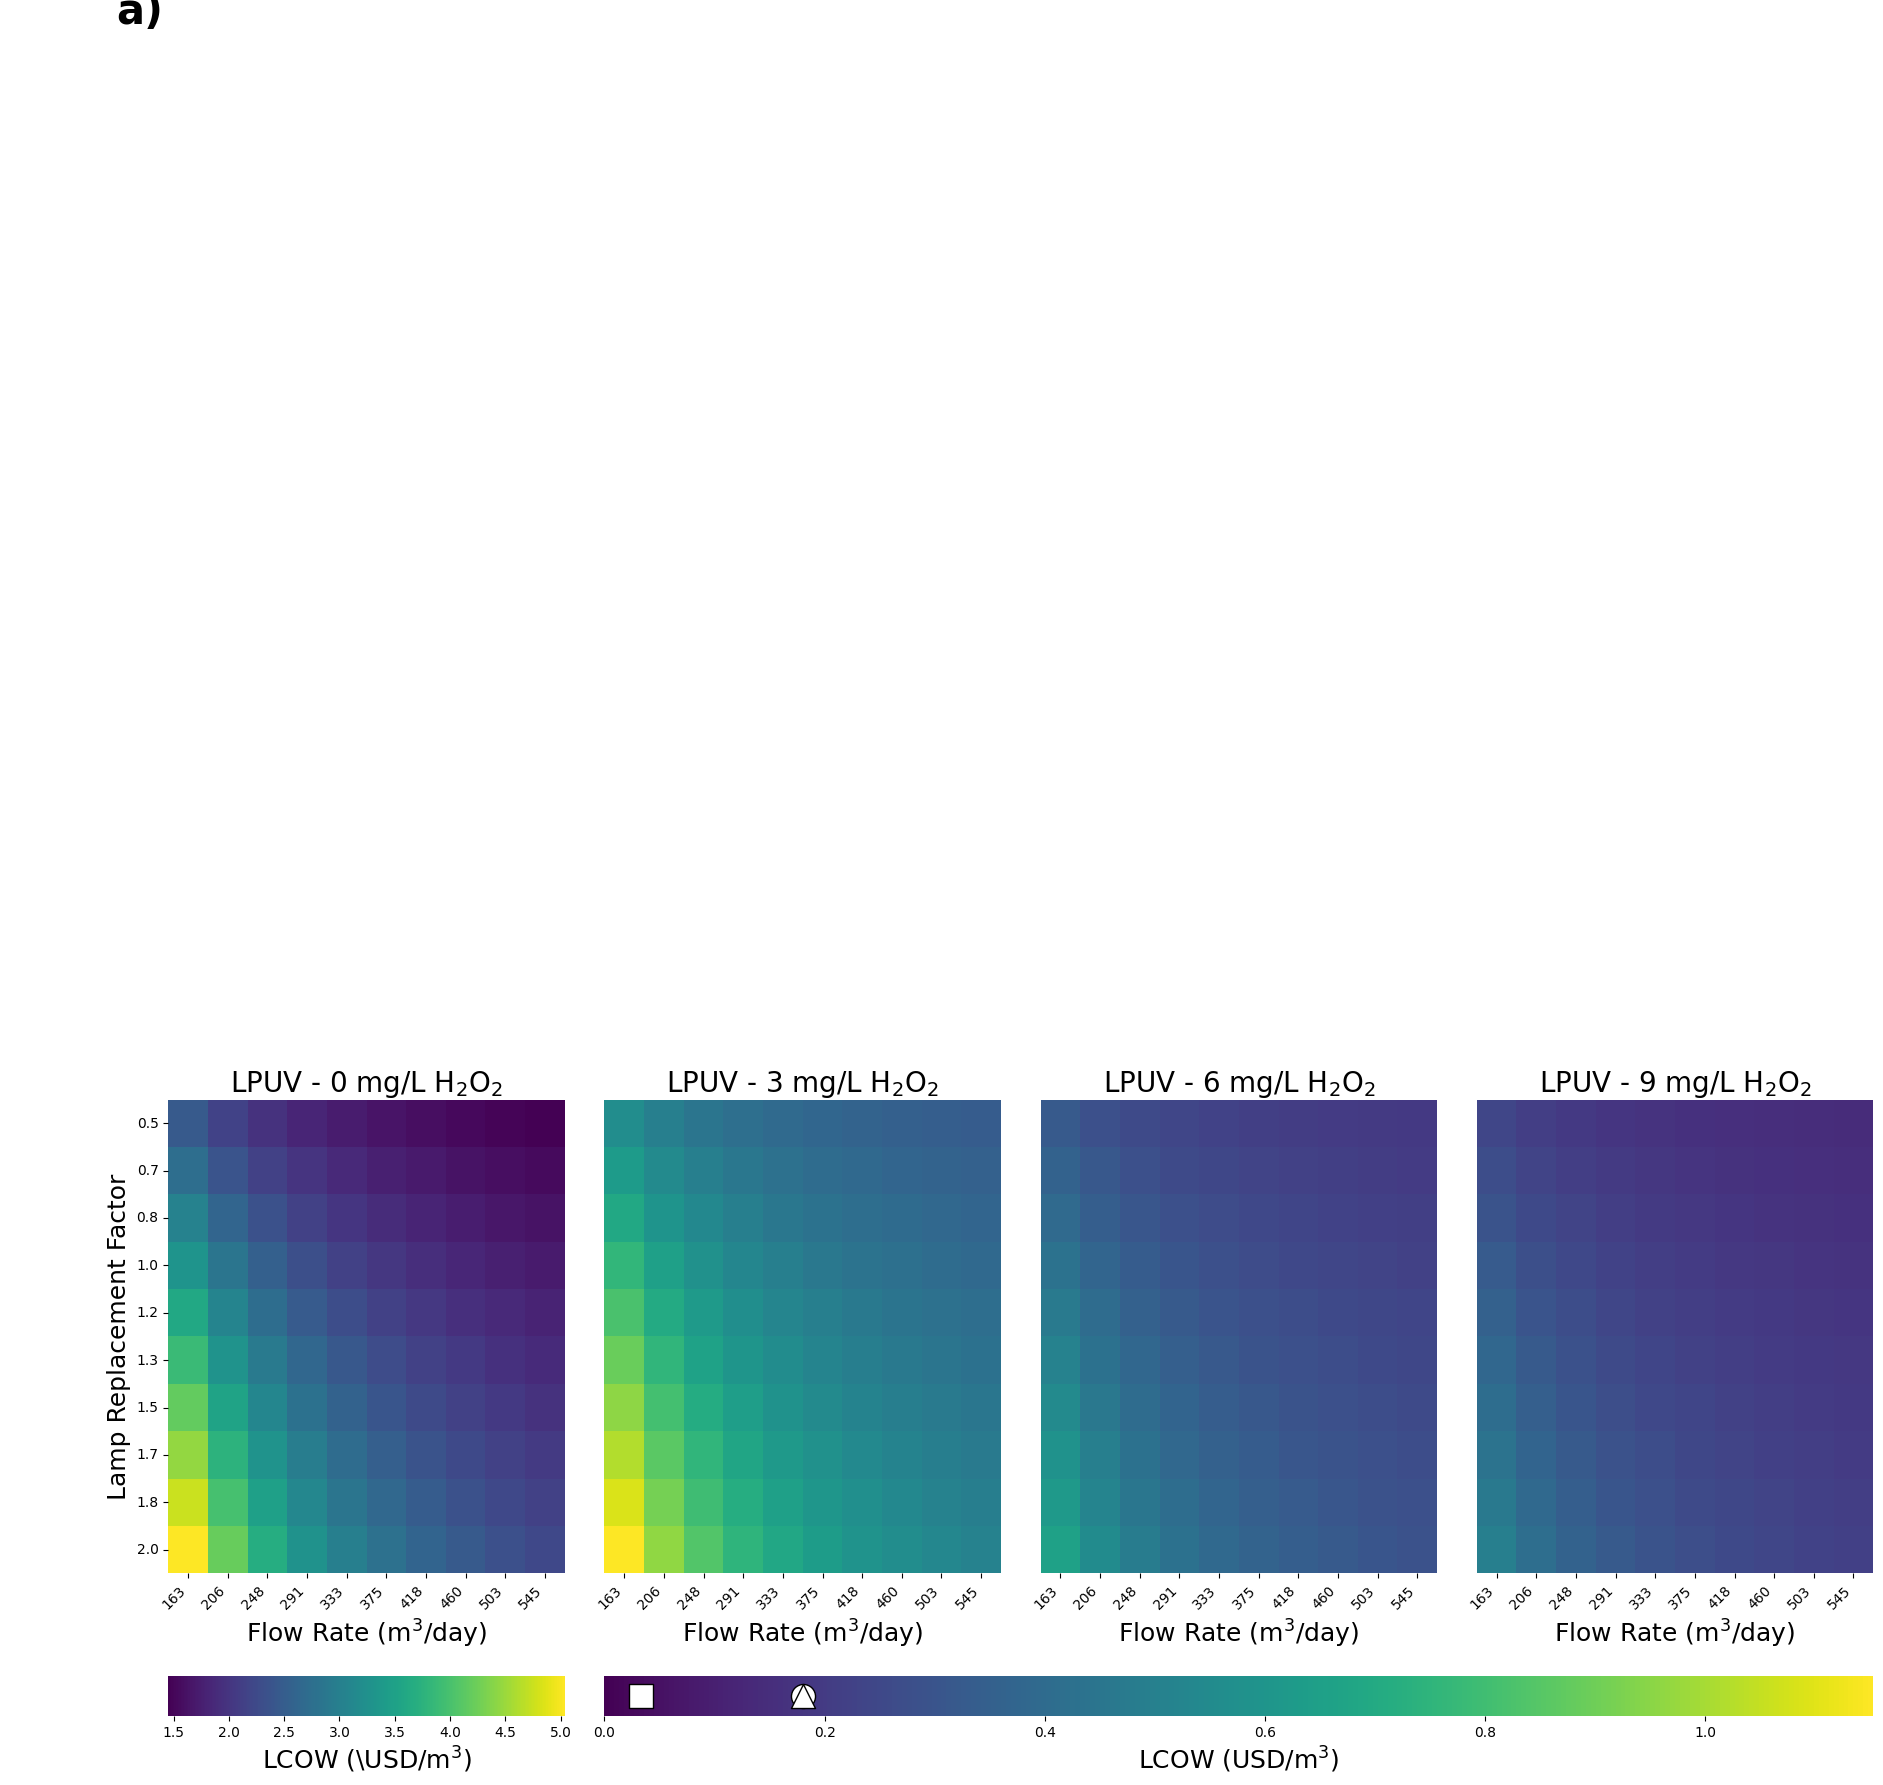

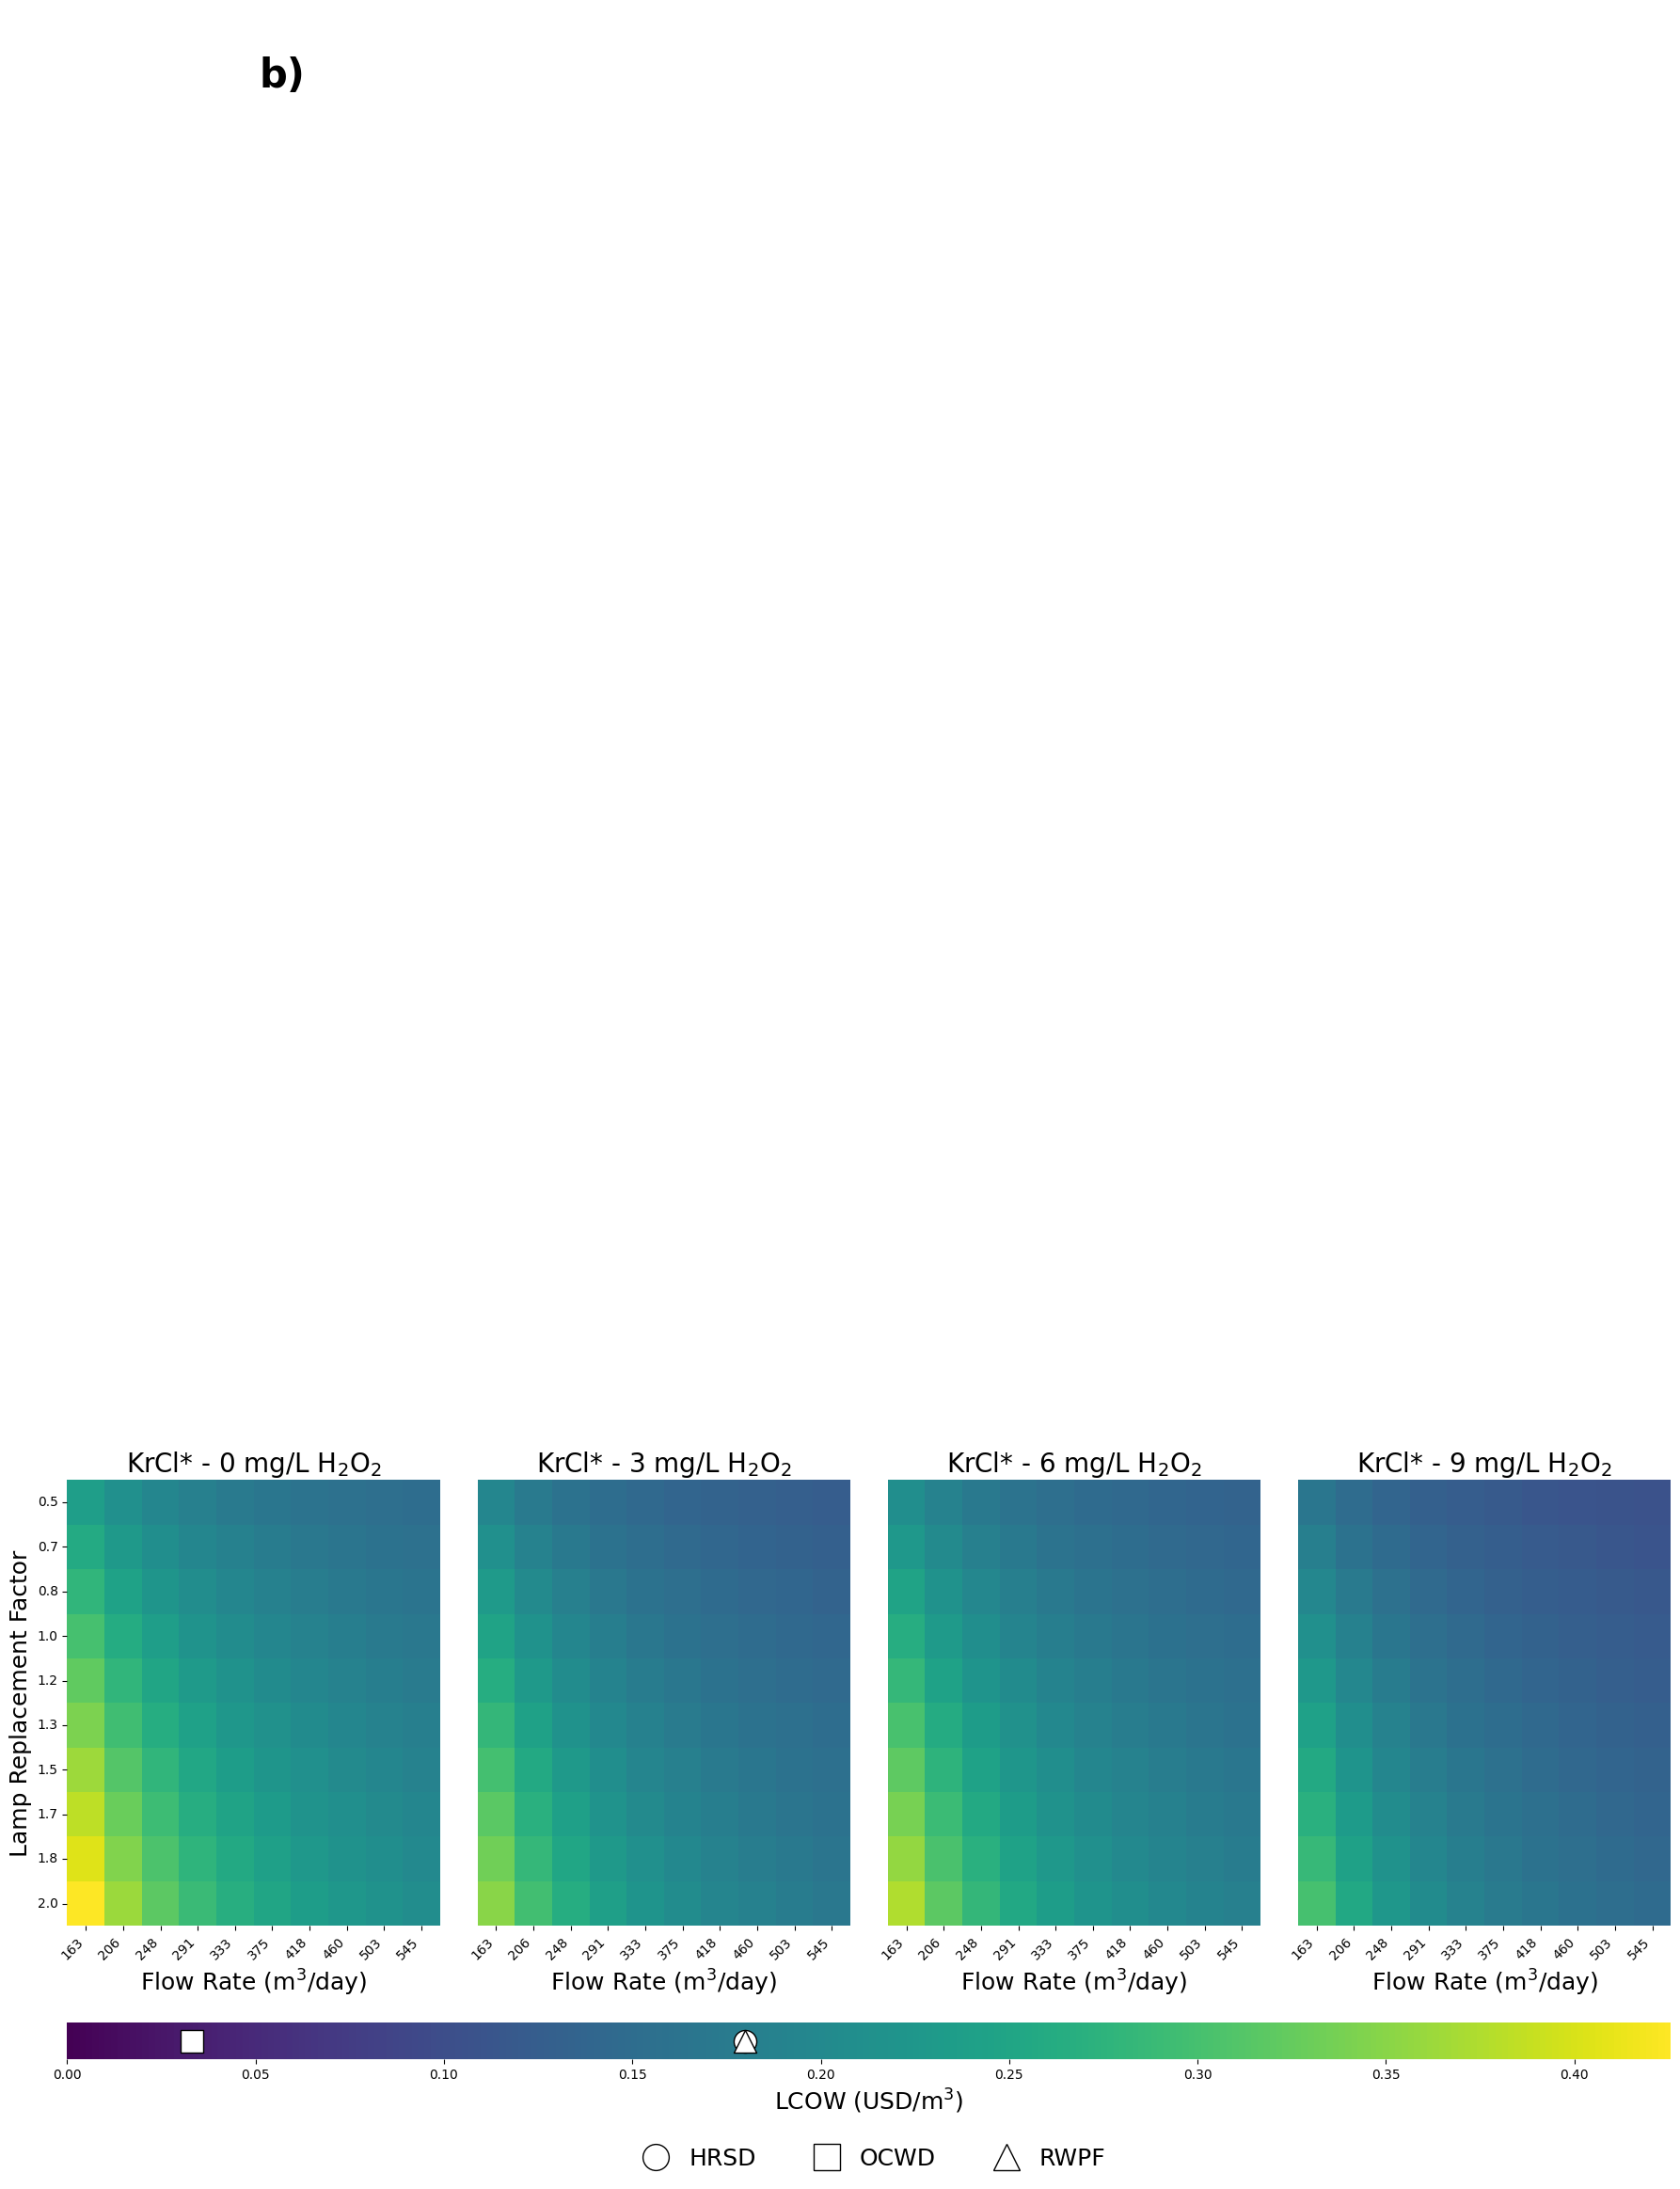

In [ ]:
#create heatmaps of sensitivity of LCOW to lamp replacement factor and flow rate (figures 6a and b)
def add_colorbar_markers(cbar_ax):
    """Define function that overlays markers on colorbar for reference LCOWs"""
    #LCOW values to mark
    values = [0.18, 0.033, 0.18]
    markers = ['o', 's', '^']
    sizes = [300, 300, 300]

    for v, m, s in zip(values, markers, sizes):
        cbar_ax.scatter(
            [v], [0.5],                
            marker=m,
            s=s,
            color='white',
            edgecolor='black',
            zorder=5,
            clip_on=False
        )

#iterate through lamp types
for lamp_type in ['LPUV', 'KrCl*']:

    #read in parameter sweep results
    df1 = pd.read_csv(f'sensitivity_results_TEA_0_{lamp_type}.csv')
    df2 = pd.read_csv(f'sensitivity_results_TEA_3_{lamp_type}.csv')
    df3 = pd.read_csv(f'sensitivity_results_TEA_6_{lamp_type}.csv')
    df4 = pd.read_csv(f'sensitivity_results_TEA_9_{lamp_type}.csv')

    #convert flow rate to m3/day
    for df in [df1, df2, df3, df4]:
        df['# Flow Rate'] = df['# Flow Rate'] * 86.4

    #pivot data
    heatmap_data_1 = df1.pivot(index='Lamp Replacement Factor', columns='# Flow Rate', values='LCOW')
    heatmap_data_2 = df2.pivot(index='Lamp Replacement Factor', columns='# Flow Rate', values='LCOW')
    heatmap_data_3 = df3.pivot(index='Lamp Replacement Factor', columns='# Flow Rate', values='LCOW')
    heatmap_data_4 = df4.pivot(index='Lamp Replacement Factor', columns='# Flow Rate', values='LCOW')

    #determine vmin/vmax for TEA scenarios 2–4 for shared scale
    all_234 = np.concatenate([df2['LCOW'], df3['LCOW'], df4['LCOW']])
    vmin_234, vmax_234 = np.nanmin(all_234), np.nanmax(all_234)
    
    #determine vmin/vmax for TEA scenarios 1–4 for shared scale
    all_1234 = np.concatenate([df1['LCOW'], df2['LCOW'], df3['LCOW'], df4['LCOW']])
    vmin_1234, vmax_1234 = np.nanmin(all_1234), np.nanmax(all_1234)

    #set up figure with gridspec
    fig = plt.figure(figsize=(22, 8))
    gs = fig.add_gridspec(
        2, 4,
        height_ratios=[12, 1],
        hspace=0.4,
        wspace=0.1
    )

    #heatmap axes (top row)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[0, 3])

    #plot LPUV lamp heatmaps
    if lamp_type == 'LPUV':
        #add colorbar axes (bottom row)
        cbar1_ax = fig.add_subplot(gs[1, 0]) #under TEA 1
        cbar234_ax = fig.add_subplot(gs[1, 1:4]) #one big bar under TEA 2–4

        #TEA 1 (own colorbar + scale)
        hm1 = sns.heatmap(
            heatmap_data_1,
            ax=ax1,
            cmap="viridis",
            cbar=True,
            vmin = df1['LCOW'].min(),
            vmax = df1['LCOW'].max(),
            cbar_ax=cbar1_ax,
            cbar_kws={"orientation": "horizontal"}
        )
        cbar1_ax.set_xlabel(r'LCOW (\USD/m$^3$)', fontsize=18)

        ax1.set_title(f'{lamp_type} - 0 mg/L H$_2$O$_2$', fontsize=20)
        ax1.set_xlabel(r'Flow Rate (m$^3$/day)', fontsize=18)
        ax1.set_ylabel('Lamp Replacement Factor', fontsize=18)
        ax1.set_yticks(np.arange(len(heatmap_data_1.index)) + 0.5)
        ax1.set_yticklabels([f'{y:.1f}' for y in heatmap_data_1.index], rotation=0)
        ax1.set_xticks(np.arange(len(heatmap_data_1.columns)) + 0.5)
        ax1.set_xticklabels([f'{x:.0f}' for x in heatmap_data_1.columns], rotation=45, ha='right')
        ax1.text(-3.3, 3.8, 'a)', transform=ax.transAxes,
        fontsize=30, fontweight='bold', va='top', ha='left')

        #TEA 2–4 (shared scale + shared colorbar)
        for ax, data, title in [
            (ax2, heatmap_data_2, '3 mg/L H$_2$O$_2$'),
            (ax3, heatmap_data_3, '6 mg/L H$_2$O$_2$'),
            (ax4, heatmap_data_4, '9 mg/L H$_2$O$_2$'),
        ]:
            sns.heatmap(
                data,
                ax=ax,
                cmap="viridis",
                vmin=0,
                vmax=vmax_234,
                cbar=(ax is ax4),
                cbar_ax=(cbar234_ax if ax is ax4 else None),
                cbar_kws={"orientation": "horizontal"}
            )
            ax.set_title(f'{lamp_type} - {title}', fontsize=20)
            ax.set_xlabel(r'Flow Rate (m$^3$/day)', fontsize=18)
            ax.set_ylabel('')
            ax.set_yticks([]) 
            ax.set_yticklabels([])
            ax.set_xticks(np.arange(len(data.columns)) + 0.5)
            ax.set_xticklabels([f'{x:.0f}' for x in data.columns], rotation=45, ha='right')
        cbar234_ax.set_xlabel(r'LCOW (USD/m$^3$)', fontsize=18)
        add_colorbar_markers(cbar234_ax)

    #plot KrCl* lamp heatmaps
    else:
        #define a single colorbar axis for TEA 1–4 (shared scale)
        cbar1234_ax = fig.add_subplot(gs[1, 0:4])   # one big bar under TEA 1–4

        #TEA 1 (own colorbar + scale)
        hm1 = sns.heatmap(
            heatmap_data_1,
            ax=ax1,
            cmap="viridis",
            cbar=(ax is ax4),
            cbar_ax=(cbar1234_ax if ax is ax4 else None),
            cbar_kws={"orientation": "horizontal"},
            vmin = 0,
            vmax = vmax_1234
        )

        ax1.set_title(f'{lamp_type} - 0 mg/L H$_2$O$_2$', fontsize=20)
        ax1.set_xlabel(r'Flow Rate (m$^3$/day)', fontsize=18)
        ax1.set_ylabel('Lamp Replacement Factor', fontsize=18)
        ax1.set_yticks(np.arange(len(data.index)) + 0.5)
        ax1.set_yticklabels([f'{y:.1f}' for y in data.index], rotation=0)
        ax1.set_xticks(np.arange(len(data.columns)) + 0.5)
        ax1.set_xticklabels([f'{x:.0f}' for x in data.columns], rotation=45, ha='right')
        ax1.text(-3.3, 4.3, 'b)', transform=ax.transAxes,
        fontsize=30, fontweight='bold', va='top', ha='left')
        
        #TEA 2–4 (shared scale + shared colorbar)
        for ax, data, title in [
            (ax2, heatmap_data_2, '3 mg/L H$_2$O$_2$'),
            (ax3, heatmap_data_3, '6 mg/L H$_2$O$_2$'),
            (ax4, heatmap_data_4, '9 mg/L H$_2$O$_2$'),
        ]:
            sns.heatmap(
                data,
                ax=ax,
                cmap="viridis",
                vmin=0,
                vmax=vmax_1234,
                cbar=(ax is ax4),
                cbar_ax=(cbar1234_ax if ax is ax4 else None),
                cbar_kws={"orientation": "horizontal"}
            )
            ax.set_title(f'{lamp_type} - {title}', fontsize=20)
            ax.set_xlabel(r'Flow Rate (m$^3$/day)', fontsize=18)
            ax.set_ylabel('')
            ax.set_yticks([]) 
            ax.set_yticklabels([])
            ax.set_xticks(np.arange(len(data.columns)) + 0.5)
            ax.set_xticklabels([f'{x:.0f}' for x in data.columns], rotation=45, ha='right')
        
        cbar1234_ax.set_xlabel(r'LCOW (USD/m$^3$)', fontsize=18)
        add_colorbar_markers(cbar1234_ax)    
        legend_labels = [
            "HRSD",
            "OCWD",
            "RWPF",
        ]

        #add legend for marker overlays on colorbar
        legend_markers = ['o', 's', '^']

        legend_elements = [
            Line2D([0], [0], marker=m, color='black', markerfacecolor='white',
                markersize=20, linestyle='None', label=lab)
            for m, lab in zip(legend_markers, legend_labels)
        ]

        cbar1234_ax.legend(
            handles=legend_elements,
            loc='upper center',
            bbox_to_anchor=(0.5, -1.8),
            ncol=4,
            frameon=False,
            fontsize=18,
            handletextpad=0.4
        )
    
    #export figure
    plt.tight_layout()
    if lamp_type == 'LPUV':
        plt.savefig(f'figure_6a.jpeg', dpi=300, bbox_inches='tight')
    else:
        plt.savefig(f'figure_6b.jpeg', dpi=300, bbox_inches='tight')    

In [ ]:
#calculate the maximum difference in LCOW across evaluated flow rates and lamp replacement factors for each TEA scenario and lamp type
lamp_type = 'LPUV'
df1 = pd.read_csv(f'sensitivity_results_TEA_0_{lamp_type}.csv')
df2 = pd.read_csv(f'sensitivity_results_TEA_3_{lamp_type}.csv')
df3 = pd.read_csv(f'sensitivity_results_TEA_6_{lamp_type}.csv')
df4 = pd.read_csv(f'sensitivity_results_TEA_9_{lamp_type}.csv')

print('max difference, 0 mg/L H2O2 LPUV: ' + str(df1['LCOW'].max() - df1['LCOW'].min()))
print('max difference, 3 mg/L H2O2 LPUV: ' + str(df2['LCOW'].max() - df2['LCOW'].min()))
print('max difference, 6 mg/L H2O2 LPUV: ' + str(df3['LCOW'].max() - df3['LCOW'].min()))
print('max difference, 9 mg/L H2O2 LPUV: ' + str(df4['LCOW'].max() - df4['LCOW'].min()))

lamp_type = 'KrCl*'
df1 = pd.read_csv(f'sensitivity_results_TEA_0_{lamp_type}.csv')
df2 = pd.read_csv(f'sensitivity_results_TEA_3_{lamp_type}.csv')
df3 = pd.read_csv(f'sensitivity_results_TEA_6_{lamp_type}.csv')
df4 = pd.read_csv(f'sensitivity_results_TEA_9_{lamp_type}.csv')

print('max difference, 0 mg/L H2O2 KrCl*: ' + str(df1['LCOW'].max() - df1['LCOW'].min()))
print('max difference, 3 mg/L H2O2 KrCl*: ' + str(df2['LCOW'].max() - df2['LCOW'].min()))
print('max difference, 6 mg/L H2O2 KrCl*: ' + str(df3['LCOW'].max() - df3['LCOW'].min()))
print('max difference, 9 mg/L H2O2 KrCl*: ' + str(df4['LCOW'].max() - df4['LCOW'].min()))

max difference, TEA 1 LPUV: 3.58525
max difference, TEA 2 LPUV: 0.8201546
max difference, TEA 3 LPUV: 0.46866
max difference, TEA 4 LPUV: 0.351495
max difference, TEA 1 KrCl*: 0.2747668
max difference, TEA 2 KrCl*: 0.2262786
max difference, TEA 3 KrCl*: 0.24244129999999997
max difference, TEA 4 KrCl*: 0.1939531
